## **Assignment 2 -Data Understanding Phase in CRISP-DM**

Group 8 - “Analysis of Customer Purchase Behavior and Marketing Campaign Effectiveness Using Retail Transaction Data”

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Dataset Source**

Public dunnhumby "The Complete Journey" dataset. Real-world grocery loyalty card data for ~2,500 households over 102 weeks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




# --- STEP 1: LOAD ALL 8 FILES ---
files = {
    'demographic': '/content/drive/MyDrive/Capstone_Project/hh_demographics.csv',
    'campaign_desc': '/content/drive/MyDrive/Capstone_Project/campaign_desc.csv',
    'campaign_table': '/content/drive/MyDrive/Capstone_Project/campaign_table.csv',
    'product': '/content/drive/MyDrive/Capstone_Project/product.csv',
    'coupon': '/content/drive/MyDrive/Capstone_Project/coupon.csv',
    'coupon_redempt': '/content/drive/MyDrive/Capstone_Project/coupon_redempt.csv',
    'transaction': '/content/drive/MyDrive/Capstone_Project/transaction_data.csv',
    'causal': '/content/drive/MyDrive/Capstone_Project/causal_data.csv'
}

## **Dataset Description**

**Structure & Size**
| File | Rows | Columns |
| :--- | :--- | :--- |
| transaction_data | 2,595,732 | 12 |
| product | 92,353 | 7 |
| hh_demographics | 801 | 8 |
| campaign_desc | 30 | 4 |
| campaign_table | 7,208 | 3 |
| coupon | 124,548 | 3 |
| coupon_redempt | 2,318 | 4 |
| causal_data | 36,786,524 | 5 |

**Variable Types**
- **Numerical:** `household_key`, `DAY`, `WEEK_NO`, `QUANTITY`, `SALES_VALUE`, `RETAIL_DISC`
- **Categorical:** `AGE_DESC`, `INCOME_DESC`, `DEPARTMENT`, `BRAND`, `DISPLAY`, `MAILER`
- **Text:** `COMMODITY_DESC`, `CURR_SIZE_OF_PRODUCT

In [3]:
# Load all files and check which ones loaded
data = {}
for name, path in files.items():
    try:
        df = pd.read_csv(path)
        data[name] = df
        print(f"{name}: LOADED, shape = {df.shape}")
    except Exception as e:
        print(f"{name}: FAILED to load -> {e}")

# verify keys and a quick preview
print("\nDataFrames loaded:", list(data.keys()))

for name in ['transaction', 'demographic']:
    if name in data:
        print(f"\nPreview of {name}:")
        print(data[name].head())

demographic: LOADED, shape = (801, 8)
campaign_desc: LOADED, shape = (30, 4)
campaign_table: LOADED, shape = (7208, 3)
product: LOADED, shape = (92353, 7)
coupon: LOADED, shape = (124548, 3)
coupon_redempt: LOADED, shape = (2318, 4)
transaction: LOADED, shape = (2595732, 12)
causal: LOADED, shape = (36786524, 5)

DataFrames loaded: ['demographic', 'campaign_desc', 'campaign_table', 'product', 'coupon', 'coupon_redempt', 'transaction', 'causal']

Preview of transaction:
   household_key    BASKET_ID  DAY  PRODUCT_ID  QUANTITY  SALES_VALUE  \
0           2375  26984851472    1     1004906         1         1.39   
1           2375  26984851472    1     1033142         1         0.82   
2           2375  26984851472    1     1036325         1         0.99   
3           2375  26984851472    1     1082185         1         1.21   
4           2375  26984851472    1     8160430         1         1.50   

   STORE_ID  RETAIL_DISC  TRANS_TIME  WEEK_NO  COUPON_DISC  COUPON_MATCH_DISC  
0      


## **ATTRIBUTE ANALYSIS**


**Customer Behavior & Profiling**
- **`household_key`** – Primary customer identifier (links transactions, demographics, campaigns).
- **`BASKET_ID`** – Defines shopping trips (trip frequency, basket value).
- **`PRODUCT_ID`** – Links to product master (brand, department).
- **`QUANTITY` & `SALES_VALUE`** – Core spend/volume metrics.
- **Demographics (`INCOME_DESC`, `AGE_DESC`, `HH_COMP_DESC`)** – Customer segmentation.

**Marketing Campaign Analysis**
- **`CAMPAIGN` & `DESCRIPTION`** – Unique campaign ID & type (TypeA/B/C).
- **`COUPON_UPC`** – Unique coupon ID; defines redemption (target variable).
- **`RETAIL_DISC`, `COUPON_DISC`** – Discount depth (price sensitivity).
- **`DISPLAY` & `MAILER`** – In-store merchandising (separates price vs. visibility).
- **`START_DAY` & `END_DAY`** – Campaign timing (pre/post analysis).

**Key Attributes by Project Goal**
| Focus Area | Primary Attributes |
| :--- | :--- |
| **Customer Profiling** | `household_key`, `INCOME_DESC`, `AGE_DESC` |
| **Campaign Effectiveness** | `CAMPAIGN`, `DESCRIPTION`, `COUPON_REDEMPT` |
| **Discount Sensitivity** | `RETAIL_DISC`, `QUANTITY`, `PRODUCT_ID` |
| **In-Store Impact** | `DISPLAY`, `MAILER`, `SALES_VALUE` |
| **Product Affinity** | `PRODUCT_ID`, `DEPARTMENT`, `BRAND` |



Datatypes of columns

In [4]:
print("--- DATA TYPES FOR ALL TABLES ---\n")

for name, df in data.items():
        print(f" File: {name}")
        print(df.dtypes)          # column -> dtype
        print("-" * 40)

--- DATA TYPES FOR ALL TABLES ---

 File: demographic
AGE_DESC               object
MARITAL_STATUS_CODE    object
INCOME_DESC            object
HOMEOWNER_DESC         object
HH_COMP_DESC           object
HOUSEHOLD_SIZE_DESC    object
KID_CATEGORY_DESC      object
household_key           int64
dtype: object
----------------------------------------
 File: campaign_desc
DESCRIPTION    object
CAMPAIGN        int64
START_DAY       int64
END_DAY         int64
dtype: object
----------------------------------------
 File: campaign_table
DESCRIPTION      object
household_key     int64
CAMPAIGN          int64
dtype: object
----------------------------------------
 File: product
PRODUCT_ID               int64
MANUFACTURER             int64
DEPARTMENT              object
BRAND                   object
COMMODITY_DESC          object
SUB_COMMODITY_DESC      object
CURR_SIZE_OF_PRODUCT    object
dtype: object
----------------------------------------
 File: coupon
COUPON_UPC    int64
PRODUCT_ID    int

Data Quality Assessment

Missing Values

In [5]:
print("--- DIAGNOSTIC MISSING DATA REPORT ---")

# 1. Check if data actually loaded
if 'data' not in locals():
    print("CRITICAL ERROR: The 'data' variable is not defined. Please run Step 1 first.")
elif not data:
    print("CRITICAL ERROR: The 'data' dictionary is empty.")
else:
    print(f"Successfully scanning {len(data)} files...\n")

    for name, df in data.items():
        print(f" File: {name}")
        missing_count = df.isnull().sum()
        total_missing = missing_count.sum()

        if total_missing > 0:
            print(f" FOUND {total_missing} MISSING VALUES:")
            print(missing_count[missing_count > 0])
        else:
            print(" Status: Clean (No standard NaNs found)")

        print(" Deep Check:")
        for col in df.columns:
            if df[col].dtype == object:
                empty_strings = (df[col] == ' ').sum() + (df[col] == '').sum()
                unknowns = df[col].astype(str).str.contains('Unknown|None', case=False, na=False).sum()
                if empty_strings > 0:
                    print(f"      - Column '{col}' has {empty_strings} empty strings/spaces")
                if unknowns > 0:
                    print(f"      - Column '{col}' has {unknowns} values labeled 'Unknown/None'")
        print("-" * 40)

--- DIAGNOSTIC MISSING DATA REPORT ---
Successfully scanning 8 files...

 File: demographic
 Status: Clean (No standard NaNs found)
 Deep Check:
      - Column 'HOMEOWNER_DESC' has 233 values labeled 'Unknown/None'
      - Column 'HH_COMP_DESC' has 73 values labeled 'Unknown/None'
      - Column 'KID_CATEGORY_DESC' has 558 values labeled 'Unknown/None'
----------------------------------------
 File: campaign_desc
 Status: Clean (No standard NaNs found)
 Deep Check:
----------------------------------------
 File: campaign_table
 Status: Clean (No standard NaNs found)
 Deep Check:
----------------------------------------
 File: product
 Status: Clean (No standard NaNs found)
 Deep Check:
      - Column 'DEPARTMENT' has 15 empty strings/spaces
      - Column 'COMMODITY_DESC' has 15 empty strings/spaces
      - Column 'COMMODITY_DESC' has 52 values labeled 'Unknown/None'
      - Column 'SUB_COMMODITY_DESC' has 15 empty strings/spaces
      - Column 'CURR_SIZE_OF_PRODUCT' has 30607 empty st

Outlier Detection - Numeric columns (IQR Method)

In [6]:
print("--- OUTLIER REPORT (IQR METHOD) Numeric Columns ---\n")

if 'data' not in locals() or not data:
    print("ERROR: 'dfs' is not defined or empty. Load the files first.")
else:
    for name, df in data.items():
        print(f" File: {name}")

        num_cols = df.select_dtypes(include=[np.number]).columns
        if len(num_cols) == 0:
            print("   No numeric columns to check.")
            print("-" * 40)
            continue

        outlier_summary = {}

        for col in num_cols:
            series = df[col].dropna()
            if series.empty:
                continue

            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            mask = (series < lower) | (series > upper)
            outlier_count = mask.sum()
            if outlier_count > 0:
                outlier_summary[col] = outlier_count

        if outlier_summary:
            print(" Outliers detected in these numeric columns:")
            for col, cnt in outlier_summary.items():
                print(f"      - {col}: {cnt} outliers")
        else:
            print(" No IQR-based outliers detected in numeric columns.")

        print("-" * 40)


--- OUTLIER REPORT (IQR METHOD) Numeric Columns ---

 File: demographic
 No IQR-based outliers detected in numeric columns.
----------------------------------------
 File: campaign_desc
 No IQR-based outliers detected in numeric columns.
----------------------------------------
 File: campaign_table
 No IQR-based outliers detected in numeric columns.
----------------------------------------
 File: product
 Outliers detected in these numeric columns:
      - MANUFACTURER: 9049 outliers
----------------------------------------
 File: coupon
 Outliers detected in these numeric columns:
      - CAMPAIGN: 15465 outliers
----------------------------------------
 File: coupon_redempt
 Outliers detected in these numeric columns:
      - DAY: 35 outliers
      - CAMPAIGN: 195 outliers
----------------------------------------
 File: transaction
 Outliers detected in these numeric columns:
      - PRODUCT_ID: 608800 outliers
      - QUANTITY: 544765 outliers
      - SALES_VALUE: 190644 outliers
 

Ignore IQR for ID fields, TRANS_TIME, MANUFACTURER since it is not a continuous field

In [7]:
#  LOGICAL CONSISTENCY (Outliers & Errors) ---
print("\n--- LOGICAL & OUTLIER CHECKS ---")

# Transaction Logic
if 'transaction' in data:
    df_trans = data['transaction']
    # Check for negative sales (Returns)
    neg_sales = df_trans[df_trans['SALES_VALUE'] < 0]
    print(f"Transactions with NEGATIVE Sales (Returns): {len(neg_sales)}")

    # Check for Zero quantity
    zero_qty = df_trans[df_trans['QUANTITY'] <= 0]
    print(f"Transactions with ZERO Quantity: {len(zero_qty)}")

#  Campaign Duration Logic
if 'campaign_desc' in data:
    df_camp = data['campaign_desc']
    # Check if End Day is before Start Day
    invalid_dates = df_camp[df_camp['END_DAY'] < df_camp['START_DAY']]
    if len(invalid_dates) > 0:
        print(f"CRITICAL: Found {len(invalid_dates)} campaigns ending before they start!")
    else:
        print("Campaign durations are valid.")


--- LOGICAL & OUTLIER CHECKS ---
Transactions with NEGATIVE Sales (Returns): 0
Transactions with ZERO Quantity: 14466
Campaign durations are valid.


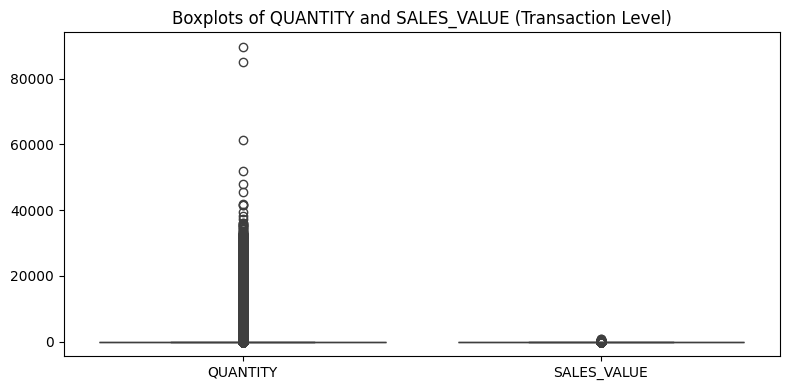

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_trans[['QUANTITY', 'SALES_VALUE']])
plt.title('Boxplots of QUANTITY and SALES_VALUE (Transaction Level)')
plt.tight_layout()
plt.show()

Inconsistencies or Errors

a. Duplicate Records

In [9]:
print("\n--- DUPLICATE ROW REPORT ---\n")

if 'data' not in locals() or not data:
    print("ERROR: 'dfs' is not defined or empty. Load the files first.")
else:
    for name, df in data.items():
        dup_count = df.duplicated().sum()
        print(f" File: {name}")
        print(f"   Duplicate rows: {dup_count}")
        if dup_count > 0:
            print("   Example duplicates:")
            print(df[df.duplicated()].head())
        print("-" * 40)



--- DUPLICATE ROW REPORT ---

 File: demographic
   Duplicate rows: 0
----------------------------------------
 File: campaign_desc
   Duplicate rows: 0
----------------------------------------
 File: campaign_table
   Duplicate rows: 0
----------------------------------------
 File: product
   Duplicate rows: 0
----------------------------------------
 File: coupon
   Duplicate rows: 5164
   Example duplicates:
      COUPON_UPC  PRODUCT_ID  CAMPAIGN
49   54100010032       34214        27
50   54100010032       34214        27
51   54100010032       34214        27
126  54589314175       48728        27
128  54589314187       48728        27
----------------------------------------
 File: coupon_redempt
   Duplicate rows: 0
----------------------------------------
 File: transaction
   Duplicate rows: 0
----------------------------------------
 File: causal
   Duplicate rows: 0
----------------------------------------


b. Checking leading/trailing spaces and inconsistent casing

In [10]:
print("\n--- FORMATTING / STRING INCONSISTENCY CHECK ---\n")

if 'data' not in locals() or not data:
    print("ERROR: 'dfs' is not defined or empty. Load the files first.")
else:
    for name, df in data.items():
        print(f" File: {name}")
        obj_cols = df.select_dtypes(include=['object']).columns
        if len(obj_cols) == 0:
            print("   No object/string columns.")
            print("-" * 40)
            continue

        for col in obj_cols:
            s = df[col].astype(str)

            # Leading/trailing spaces
            with_space = (s != s.str.strip()).sum()

            # Count distinct raw vs stripped values as a signal of messy formatting
            unique_raw = s.nunique(dropna=False)
            unique_stripped = s.str.strip().nunique(dropna=False)

            if with_space > 0 or unique_raw != unique_stripped:
                print(f"   Column '{col}':")
                if with_space > 0:
                    print(f"      - {with_space} values with leading/trailing spaces")
                if unique_raw != unique_stripped:
                    print(f"      - Different unique counts raw({unique_raw}) vs stripped({unique_stripped})")

        print("-" * 40)



--- FORMATTING / STRING INCONSISTENCY CHECK ---

 File: demographic
----------------------------------------
 File: campaign_desc
----------------------------------------
 File: campaign_table
----------------------------------------
 File: product
   Column 'DEPARTMENT':
      - 15 values with leading/trailing spaces
   Column 'COMMODITY_DESC':
      - 15 values with leading/trailing spaces
   Column 'SUB_COMMODITY_DESC':
      - 15 values with leading/trailing spaces
   Column 'CURR_SIZE_OF_PRODUCT':
      - 30607 values with leading/trailing spaces
----------------------------------------
 File: coupon
   No object/string columns.
----------------------------------------
 File: coupon_redempt
   No object/string columns.
----------------------------------------
 File: transaction
   No object/string columns.
----------------------------------------
 File: causal
----------------------------------------


In [11]:
# REFERENTIAL INTEGRITY (The 'Join' Validations) ---
print("\n--- REFERENTIAL INTEGRITY CHECKS ---")

if 'transaction' in data and 'product' in data:
    trans_prods = set(data['transaction']['PRODUCT_ID'])
    master_prods = set(data['product']['PRODUCT_ID'])
    missing_prods = trans_prods - master_prods
    print(f"Products sold but missing from Product Master: {len(missing_prods)}")

if 'transaction' in data and 'demographic' in data:
    trans_hh = set(data['transaction']['household_key'])
    demo_hh = set(data['demographic']['household_key'])
    missing_demo = trans_hh - demo_hh
    print(f"Households with transactions but NO demographic info: {len(missing_demo)}")

if 'causal' in data and 'product' in data:
    causal_prods = set(data['causal']['PRODUCT_ID'])
    master_prods = set(data['product']['PRODUCT_ID'])
    missing_causal = causal_prods - master_prods
    print(f"Products in Causal data (Display/Mailers) but missing from Master: {len(missing_causal)}")


--- REFERENTIAL INTEGRITY CHECKS ---
Products sold but missing from Product Master: 0
Households with transactions but NO demographic info: 1699
Products in Causal data (Display/Mailers) but missing from Master: 0


In [12]:
if 'data' in locals():
    print("--- ADVANCED DATA QUALITY CHECKS ---\n")

    # 1. UNIT CONSISTENCY CHECK (Product Table)
    if 'product' in data:
        print("1. [product.csv] Size Unit Variation:")
        # Extract the text part of the size (e.g., 'OZ', 'LB')
        sizes = data['product']['CURR_SIZE_OF_PRODUCT'].astype(str)
        # simplistic extraction of the last word as 'Unit'
        units = sizes.apply(lambda x: x.split()[-1] if len(x.split()) > 0 else 'Unknown')
        print(f"   Top 10 Units found: {units.value_counts().head(10).to_dict()}")
        print("   -> NOTE: You will need to standardize these later for analysis.\n")

    # 2. CLASS IMBALANCE CHECK (Redemption Table)
    if 'coupon_redempt' in data and 'campaign_table' in data:
        print("2. [Target Variable] Class Imbalance:")
        total_targeted = len(data['campaign_table']) # Total opportunities
        total_redeemed = len(data['coupon_redempt']) # Total successes

        redemption_rate = (total_redeemed / total_targeted) * 100
        print(f"   Total Targeted Households: {total_targeted}")
        print(f"   Total Redemptions: {total_redeemed}")
        print(f"   Global Redemption Rate: {redemption_rate:.2f}%")

        if redemption_rate < 5:
            print("   -> CRITICAL: Extreme Class Imbalance detected. You MUST use SMOTE or Stratified Sampling.")
        else:
            print("   -> Balance is acceptable.")

    # 3. TEMPORAL CONTINUITY (Transaction Table)
    if 'transaction' in data:
        print("\n3. [transaction_data] Time Continuity:")
        # Ensure DAY is sorted
        days = sorted(data['transaction']['DAY'].unique())
        full_range = range(min(days), max(days) + 1)
        missing_days = set(full_range) - set(days)

        if missing_days:
            print(f"   WARNING: Missing data for {len(missing_days)} days in the timeline!")
            print(f"   Missing Days: {list(missing_days)[:10]} ...")
        else:
            print("   SUCCESS: No gaps in transaction timeline.")

else:
    print("Please run the 'Load Data' step first.")

--- ADVANCED DATA QUALITY CHECKS ---

1. [product.csv] Size Unit Variation:
   Top 10 Units found: {'OZ': 44318, 'Unknown': 30607, 'CT': 5053, 'LB': 2283, 'ML': 1482, 'LTR': 781, 'PK': 685, 'IN': 568, 'INCH': 448, 'OUNCE': 275}
   -> NOTE: You will need to standardize these later for analysis.

2. [Target Variable] Class Imbalance:
   Total Targeted Households: 7208
   Total Redemptions: 2318
   Global Redemption Rate: 32.16%
   -> Balance is acceptable.

3. [transaction_data] Time Continuity:
   SUCCESS: No gaps in transaction timeline.


Exploratory Data Analysis

Summary statistics

In [13]:
# summary for all tables
for name, df in data.items():
    print(f"\n=== SUMMARY: {name} ===")
    print("Numeric columns:")
    print(df.describe().T)          # count, mean, std, min, 25%, 50%, 75%, max
    print("\nCategorical columns:")
    obj_cols = df.select_dtypes(include=['object']).columns
    if len(obj_cols) > 0:
        print(df[obj_cols].describe().T)  # count, unique, top, freq
    else:
        print("  (none)")



=== SUMMARY: demographic ===
Numeric columns:
               count        mean         std  min    25%     50%     75%  \
household_key  801.0  1235.17603  736.804647  1.0  596.0  1218.0  1914.0   

                  max  
household_key  2499.0  

Categorical columns:
                    count unique               top freq
AGE_DESC              801      6             45-54  288
MARITAL_STATUS_CODE   801      3                 U  344
INCOME_DESC           801     12            50-74K  192
HOMEOWNER_DESC        801      5         Homeowner  504
HH_COMP_DESC          801      6  2 Adults No Kids  255
HOUSEHOLD_SIZE_DESC   801      5                 2  318
KID_CATEGORY_DESC     801      4      None/Unknown  558

=== SUMMARY: campaign_desc ===
Numeric columns:
           count        mean         std    min     25%    50%     75%    max
CAMPAIGN    30.0   15.500000    8.803408    1.0    8.25   15.5   22.75   30.0
START_DAY   30.0  463.866667  134.488490  224.0  360.00  470.0  584.00  659.0

--- [1] Household Demographics ---
       INCOME_DESC AGE_DESC HOMEOWNER_DESC
count          801      801            801
unique          12        6              5
top         50-74K    45-54      Homeowner
freq           192      288            504


/tmp/ipykernel_5579/1195772485.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='INCOME_DESC', data=hh_demographic, order=income_order, palette='viridis')
/tmp/ipykernel_5579/1195772485.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='AGE_DESC', data=hh_demographic, order=age_order, palette='magma')
/tmp/ipykernel_5579/1195772485.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HOMEOWNER_DESC', data=hh_demographic, palette='coolwarm')


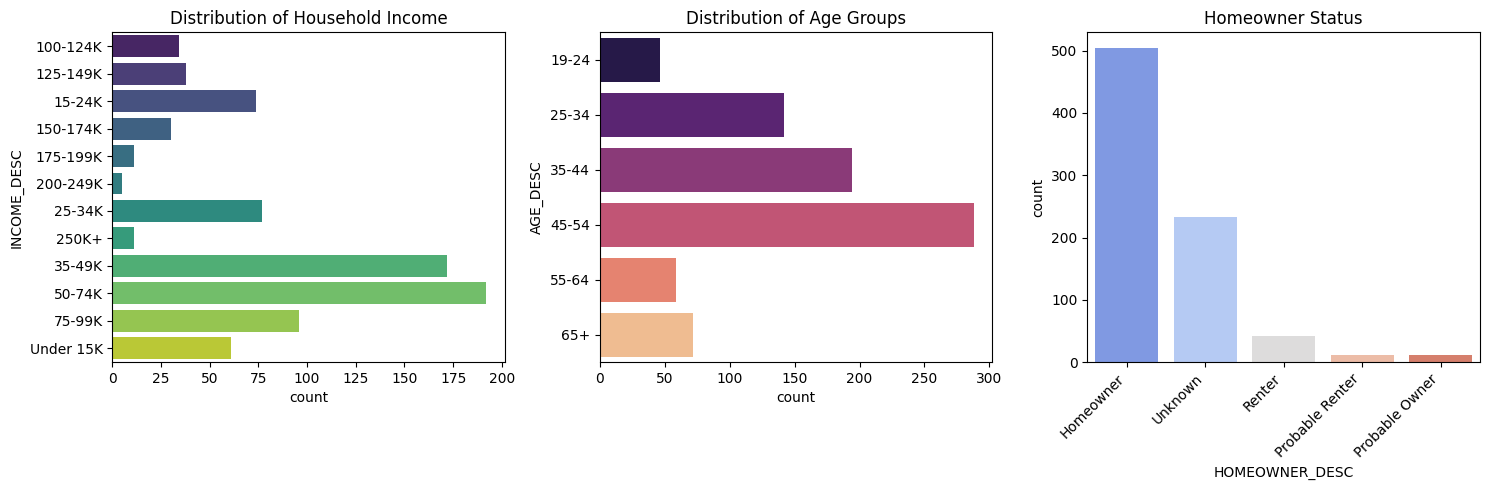


--- [2] Product Catalog Summary ---
Total Products: 92353
Unique Departments: 44


/tmp/ipykernel_5579/1195772485.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_depts.values, y=top_depts.index, palette='Blues_r')


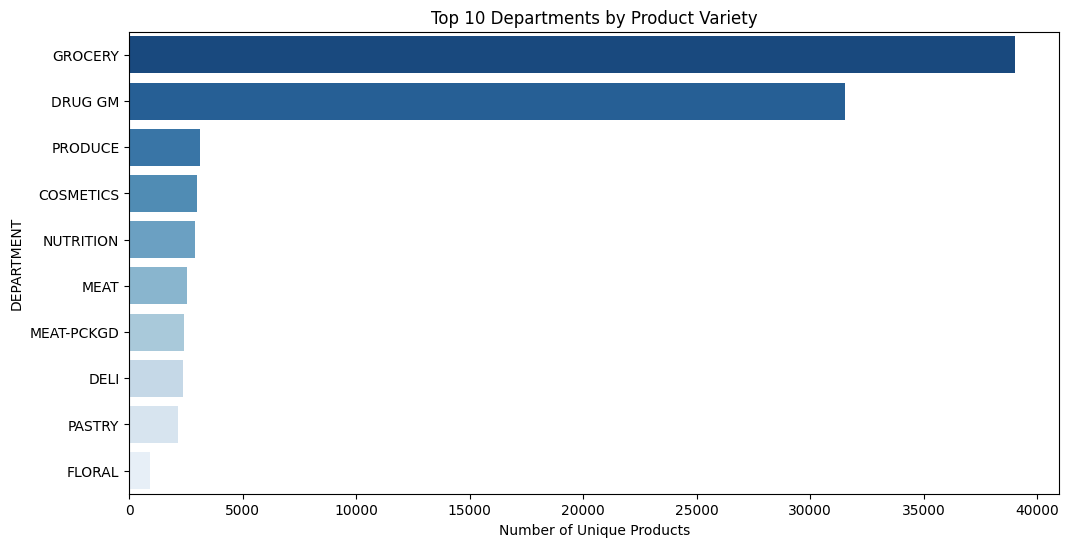


--- [3] Campaign Strategy ---
         Duration
count   30.000000
mean    46.600000
std     24.856277
min     32.000000
25%     32.000000
50%     37.500000
75%     54.500000
max    161.000000


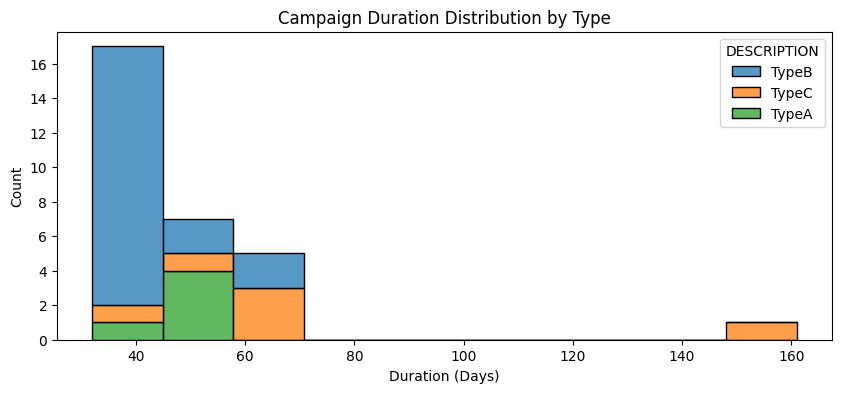


--- [4] Redemption Patterns ---


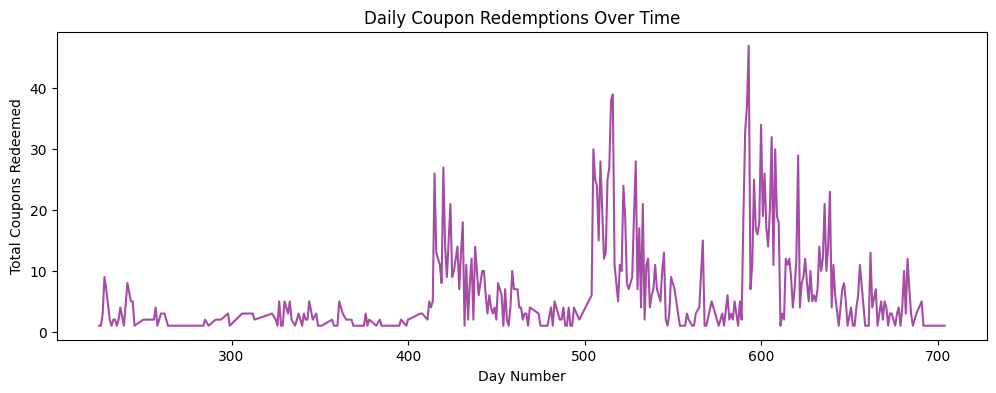

In [14]:
# Extract dataframes from the dictionary first
hh_demographic = data['demographic']
product = data['product']
campaign_desc = data['campaign_desc']
coupon_redempt = data['coupon_redempt']

# --- 1. DEMOGRAPHIC PROFILING ---
print("--- [1] Household Demographics ---")
print(hh_demographic[['INCOME_DESC', 'AGE_DESC', 'HOMEOWNER_DESC']].describe())

plt.figure(figsize=(15, 5))

# Plot Income Levels
plt.subplot(1, 3, 1)
income_order = sorted(hh_demographic['INCOME_DESC'].unique())
sns.countplot(y='INCOME_DESC', data=hh_demographic, order=income_order, palette='viridis')
plt.title('Distribution of Household Income')

# Plot Age Groups
plt.subplot(1, 3, 2)
age_order = sorted(hh_demographic['AGE_DESC'].unique())
sns.countplot(y='AGE_DESC', data=hh_demographic, order=age_order, palette='magma')
plt.title('Distribution of Age Groups')

# Plot Homeownership
plt.subplot(1, 3, 3)
sns.countplot(x='HOMEOWNER_DESC', data=hh_demographic, palette='coolwarm')
plt.title('Homeowner Status')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# --- 2. PRODUCT CATALOG ANALYSIS ---
print("\n--- [2] Product Catalog Summary ---")
print(f"Total Products: {len(product)}")
print(f"Unique Departments: {product['DEPARTMENT'].nunique()}")

plt.figure(figsize=(12, 6))
top_depts = product['DEPARTMENT'].value_counts().head(10)
sns.barplot(x=top_depts.values, y=top_depts.index, palette='Blues_r')
plt.title('Top 10 Departments by Product Variety')
plt.xlabel('Number of Unique Products')
plt.show()

# --- 3. CAMPAIGN DURATION ANALYSIS ---
print("\n--- [3] Campaign Strategy ---")
campaign_desc['Duration'] = campaign_desc['END_DAY'] - campaign_desc['START_DAY']
print(campaign_desc[['Duration', 'DESCRIPTION']].describe())

plt.figure(figsize=(10, 4))
sns.histplot(data=campaign_desc, x='Duration', hue='DESCRIPTION', multiple='stack', bins=10)
plt.title('Campaign Duration Distribution by Type')
plt.xlabel('Duration (Days)')
plt.show()

# --- 4. REDEMPTION TIMELINE ---
print("\n--- [4] Redemption Patterns ---")
daily_redemptions = coupon_redempt.groupby('DAY').size()

plt.figure(figsize=(12, 4))
plt.plot(daily_redemptions.index, daily_redemptions.values, color='purple', alpha=0.7)
plt.title('Daily Coupon Redemptions Over Time')
plt.xlabel('Day Number')
plt.ylabel('Total Coupons Redeemed')
plt.show()

Merged Dataset Shape: (1856, 11)


/tmp/ipykernel_5579/463668495.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=redempt_by_income.index, y=redempt_by_income.values, palette='rocket')


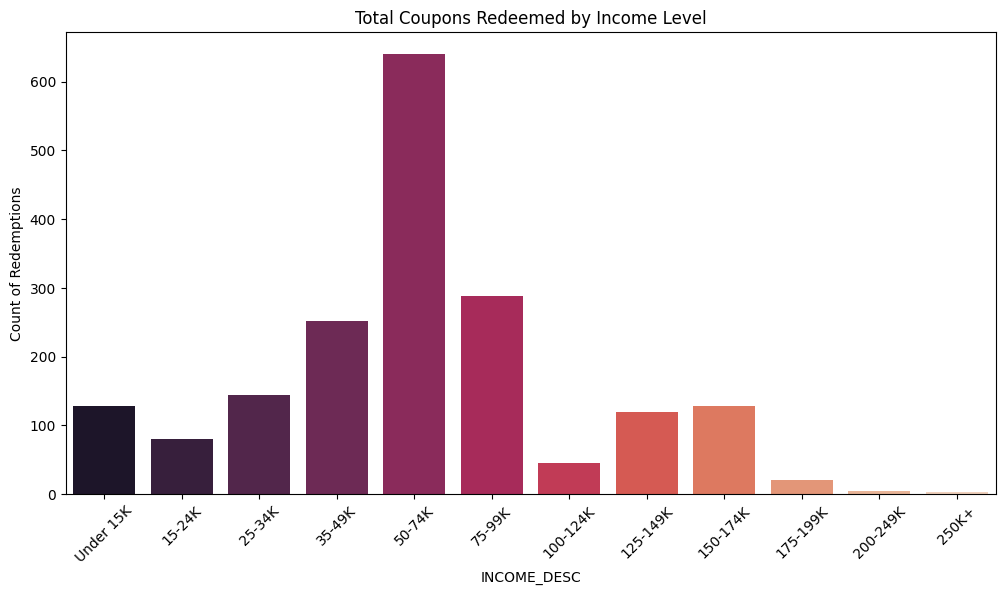

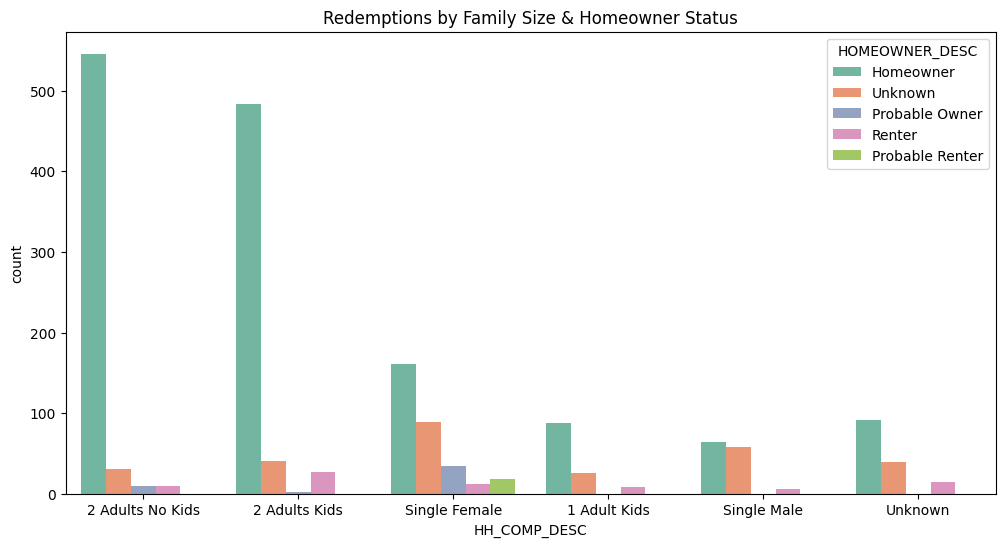

In [15]:
# --- MERGED EDA: Demographics vs. Behavior ---

# 1. Merge Demographics with Redemptions
# We use 'inner' join because we only care about households that actually redeemed
merged_df = pd.merge(coupon_redempt, hh_demographic, on='household_key', how='inner')

print(f"Merged Dataset Shape: {merged_df.shape}")

income_order = [
    'Under 15K', '15-24K', '25-34K', '35-49K', '50-74K',
    '75-99K', '100-124K', '125-149K', '150-174K', '175-199K',
    '200-249K', '250K+'
]

merged_df['INCOME_DESC'] = pd.Categorical(
    merged_df['INCOME_DESC'],
    categories=income_order,
    ordered=True
)

# 2. Visualization: Who Redeems the Most?
plt.figure(figsize=(12, 6))

# Redemption Volume by Income Level
redempt_by_income = merged_df['INCOME_DESC'].value_counts().sort_index()

sns.barplot(x=redempt_by_income.index, y=redempt_by_income.values, palette='rocket')
plt.title('Total Coupons Redeemed by Income Level')
plt.xticks(rotation=45)
plt.ylabel('Count of Redemptions')
plt.show()

# 3. Visualization: Redemption by Family Size
plt.figure(figsize=(12, 6))
sns.countplot(data=merged_df, x='HH_COMP_DESC', hue='HOMEOWNER_DESC', palette='Set2')
plt.title('Redemptions by Family Size & Homeowner Status')
plt.show()

Store Performance and Customer Behaviour

In [16]:
trans = data['transaction']
prod = data['product']

# Merge transaction with product to get department
trans_prod = trans.merge(prod[['PRODUCT_ID', 'DEPARTMENT']],
                         on='PRODUCT_ID', how='left')

# Per store, per household (Household level aggregation with each store)
store_hh = (trans_prod
            .groupby(['STORE_ID', 'household_key'])
            .agg(total_spend=('SALES_VALUE', 'sum'),
                 trip_count=('BASKET_ID', 'nunique'),
                 avg_line_value=('SALES_VALUE', 'mean'),
                 category_breadth=('DEPARTMENT', 'nunique'))
            .reset_index())

# Aggregate to store level
store_perf = (store_hh
              .groupby('STORE_ID')
              .agg(avg_spend_per_hh=('total_spend', 'mean'),
                   avg_trips_per_hh=('trip_count', 'mean'),
                   avg_line_value=('avg_line_value', 'mean'),
                   avg_category_breadth=('category_breadth', 'mean'))
              .reset_index())


Top 10 Stores with average spend per household

/tmp/ipykernel_5579/3396423025.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_stores, x='STORE_ID', y='avg_spend_per_hh', palette='Blues_d')


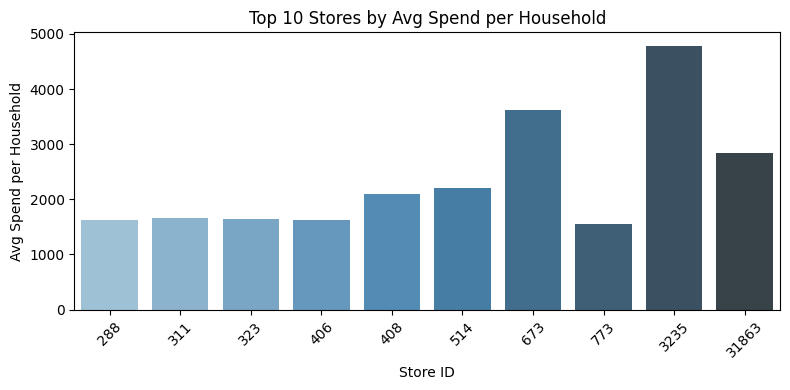

In [17]:
top_stores = (store_perf
              .sort_values('avg_spend_per_hh', ascending=False)
              .head(10))

plt.figure(figsize=(8,4))
sns.barplot(data=top_stores, x='STORE_ID', y='avg_spend_per_hh', palette='Blues_d')
plt.title('Top 10 Stores by Avg Spend per Household')
plt.xlabel('Store ID')
plt.ylabel('Avg Spend per Household')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Store Level Trips vs Spend

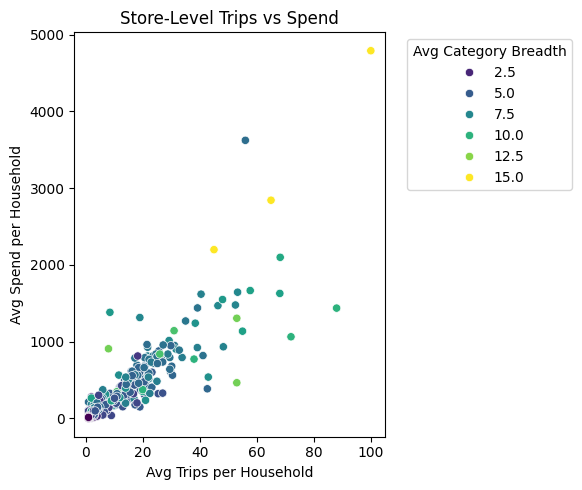

In [18]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=store_perf,
                x='avg_trips_per_hh',
                y='avg_spend_per_hh',
                hue='avg_category_breadth',
                palette='viridis')
plt.title('Store-Level Trips vs Spend')
plt.xlabel('Avg Trips per Household')
plt.ylabel('Avg Spend per Household')
plt.legend(title='Avg Category Breadth', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Category Involvement

In [19]:
# weekly involvement per household & department
cat_repeat = (trans_prod
              .groupby(['household_key', 'DEPARTMENT'])
              .agg(weeks_active=('WEEK_NO', 'nunique'),
                   trips=('BASKET_ID', 'nunique'),
                   cat_spend=('SALES_VALUE', 'sum'))
              .reset_index())

cat_metrics = (cat_repeat
               .groupby('DEPARTMENT')
               .agg(avg_weeks_active=('weeks_active', 'mean'),
                    avg_trips=('trips', 'mean'),
                    total_spend=('cat_spend', 'sum'),
                    hh_coverage=('household_key', 'nunique'))
               .reset_index())


/tmp/ipykernel_5579/159916446.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_depts, x='DEPARTMENT', y='avg_weeks_active', palette='Greens_d')


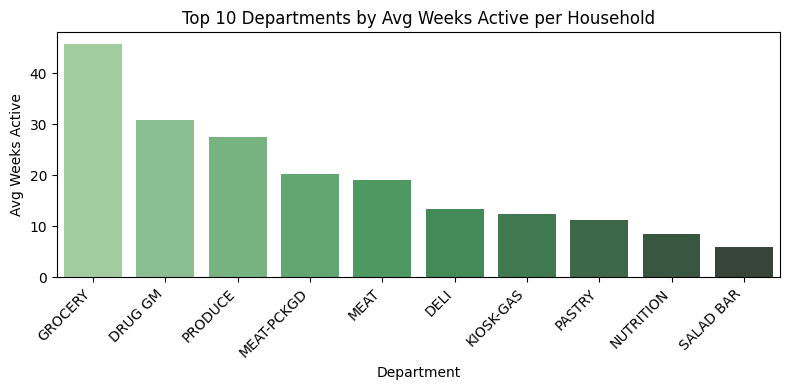

In [20]:
top_depts = (cat_metrics
             .sort_values('avg_weeks_active', ascending=False)
             .head(10))

plt.figure(figsize=(8,4))
sns.barplot(data=top_depts, x='DEPARTMENT', y='avg_weeks_active', palette='Greens_d')
plt.title('Top 10 Departments by Avg Weeks Active per Household')
plt.xlabel('Department')
plt.ylabel('Avg Weeks Active')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


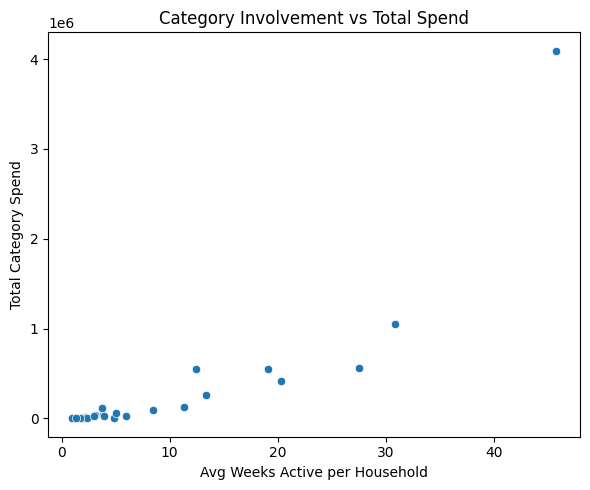

In [21]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=cat_metrics,
                x='avg_weeks_active',
                y='total_spend')
plt.title('Category Involvement vs Total Spend')
plt.xlabel('Avg Weeks Active per Household')
plt.ylabel('Total Category Spend')
plt.tight_layout()
plt.show()


Discount Dependence and its Depth across brands

In [22]:
trans = data['transaction'].copy()

trans['retailer_disc_total'] = trans['RETAIL_DISC'].fillna(0) + trans['COUPON_MATCH_DISC'].fillna(0)
trans['disc_pct'] = trans['retailer_disc_total'] / trans['SALES_VALUE'].replace(0, np.nan)


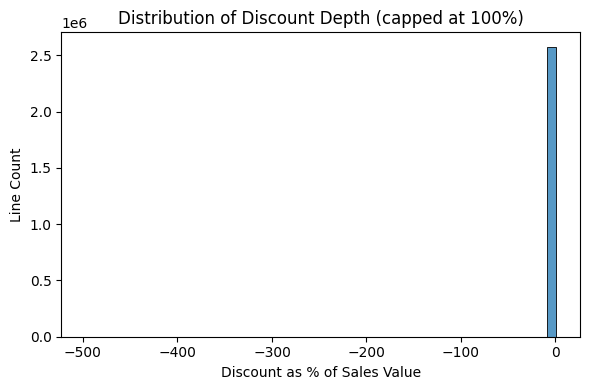

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(trans['disc_pct'].dropna().clip(upper=1), bins=50)
plt.title('Distribution of Discount Depth (capped at 100%)')
plt.xlabel('Discount as % of Sales Value')
plt.ylabel('Line Count')
plt.tight_layout()
plt.show()


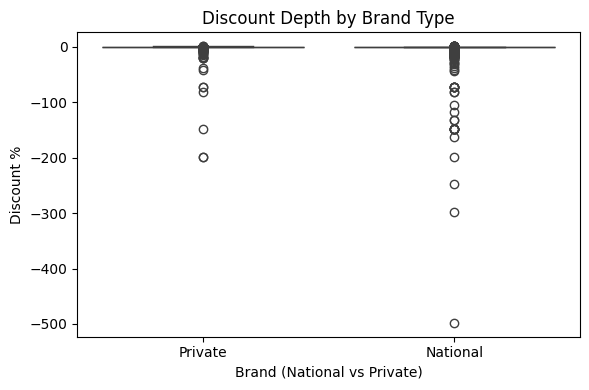

In [24]:
# merge BRAND into transaction
prod = data['product']
trans_brand = trans.merge(prod[['PRODUCT_ID', 'BRAND']], on='PRODUCT_ID', how='left')

plt.figure(figsize=(6,4))
sns.boxplot(data=trans_brand, x='BRAND', y='disc_pct')
plt.title('Discount Depth by Brand Type')
plt.xlabel('Brand (National vs Private)')
plt.ylabel('Discount %')
plt.tight_layout()
plt.show()


**Data Cleaning/Preparation**

Handling Missing Values

In [25]:
clean_data = {name: df.copy() for name, df in data.items()}

for name, df in clean_data.items():

    # Replace empty strings with NaN
    df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

    # Replace Unknown / None text
    df.replace(['Unknown', 'None', 'unknown'], np.nan, inplace=True)

    clean_data[name] = df

# -----------------  Demographic Table -----------------------
demo = clean_data['demographic']

demo['HOMEOWNER_DESC'] = demo['HOMEOWNER_DESC'].fillna('Unknown')
demo['HH_COMP_DESC'] = demo['HH_COMP_DESC'].fillna('Unknown')
demo['KID_CATEGORY_DESC'] = demo['KID_CATEGORY_DESC'].fillna('Unknown')

clean_data['demographic'] = demo

#------------------  Product Table ----------------------------
product = clean_data['product']

product['DEPARTMENT'] = product['DEPARTMENT'].fillna('Not Specified')
product['COMMODITY_DESC'] = product['COMMODITY_DESC'].fillna('Not Specified')
product['SUB_COMMODITY_DESC'] = product['SUB_COMMODITY_DESC'].fillna('Not Specified')
product['CURR_SIZE_OF_PRODUCT'] = product['CURR_SIZE_OF_PRODUCT'].fillna('Not Specified')

clean_data['product'] = product

print("---- FINAL CLEANING CHECK ----")

for name, df in clean_data.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values remaining")


---- FINAL CLEANING CHECK ----
demographic: 0 missing values remaining
campaign_desc: 0 missing values remaining
campaign_table: 0 missing values remaining
product: 0 missing values remaining
coupon: 0 missing values remaining
coupon_redempt: 0 missing values remaining
transaction: 0 missing values remaining
causal: 0 missing values remaining


Removing Inconsistent Formatting or Errors

a. Removing Leading/Trailing whitespaces

In [26]:
product = clean_data['product']

# Columns with string formatting issues
cols_to_clean = ['DEPARTMENT', 'COMMODITY_DESC', 'SUB_COMMODITY_DESC', 'CURR_SIZE_OF_PRODUCT']

# Remove leading and trailing spaces
for col in cols_to_clean:
    product[col] = product[col].str.strip()

clean_data['product'] = product

print("Leading and trailing spaces removed from product table.")

Leading and trailing spaces removed from product table.


b. Removing Duplicate Records

In [27]:
coupon = clean_data['coupon']

coupon = coupon.drop_duplicates(subset=['COUPON_UPC', 'PRODUCT_ID', 'CAMPAIGN'])

clean_data['coupon'] = coupon

print("Final coupon table shape:", clean_data['coupon'].shape)
print("Remaining duplicates:", clean_data['coupon'].duplicated().sum())


Final coupon table shape: (119384, 3)
Remaining duplicates: 0


Handling Transaction data with zero quantity value

Transactions with quantity equal to zero and sales value equal to zero were removed as they represent system-generated records with no actual purchase activity. Transactions with zero quantity but non-zero monetary values were retained and flagged, as they may represent coupon adjustments or accounting corrections.

In [28]:
zero_qty = clean_data['transaction'][clean_data['transaction']['QUANTITY'] == 0]

zero_qty[['QUANTITY','SALES_VALUE','RETAIL_DISC','COUPON_DISC']].describe()


,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC
count,14466.0,14466.000000,14466.000000,14466.000000
mean,0.0,0.001333,0.000169,-0.713987
std,0.0,0.059967,0.022250,1.682890
min,0.0,0.000000,-0.860000,-37.930000
25%,0.0,0.000000,0.000000,-1.000000
50%,0.0,0.000000,0.000000,0.000000
75%,0.0,0.000000,0.000000,0.000000
max,0.0,5.820000,2.090000,0.000000


In [29]:
zero_qty.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
97,744,26985165432,1,5978648,0,0.0,31582,0.0,1119,1,0.0,0.0
128,1287,26985336468,1,5978648,0,0.0,304,0.0,1351,1,0.0,0.0
249,2305,26996870743,2,5978656,0,0.0,414,0.0,1300,1,-1.0,0.0
293,271,26997082949,2,5978656,0,0.0,329,0.0,1719,1,-2.0,0.0
694,315,27008952267,3,957951,0,0.0,327,0.0,1707,1,0.0,0.0


In [30]:
# Removing Zero quantity and zero sales value transaction
clean_data['transaction'] = clean_data['transaction'][~((clean_data['transaction']['QUANTITY'] == 0) &(clean_data['transaction']['SALES_VALUE'] == 0))]

#Checking remaining zero quantity transaction data
remaining_zero_qty = clean_data['transaction'][clean_data['transaction']['QUANTITY'] == 0]
print("Remaining transactions with QUANTITY = 0:", remaining_zero_qty.shape[0])

Remaining transactions with QUANTITY = 0: 67


In [31]:
# Flag records with (sale_value ≠ 0 & qty = 0 as 1) and (normal transaction as 0)
clean_data['transaction']['ZERO_QTY_FLAG'] = (clean_data['transaction']['QUANTITY'] == 0).astype(int)
clean_data['transaction']['ZERO_QTY_FLAG'].value_counts()


,count
ZERO_QTY_FLAG,
0,2581266
1,67


Flagging transaction data for households with demographic information

In [32]:
# Get households present in demographic table
valid_households = set(clean_data['demographic']['household_key'])

# Create flag column
clean_data['transaction']['Missing_Demo_flag'] =  (
    ~clean_data['transaction']['household_key'].isin(valid_households)
).astype(int)


In [33]:
clean_data['transaction']['Missing_Demo_flag'].value_counts()

,count
Missing_Demo_flag,
0,1419165
1,1162168


**Brijesh Part**

Revert the Transaction Data Filter: y filtering the transaction data to only include the 801 households with demographic info, you just accidentally deleted approximately 68% of your core sales data (roughly 1.7 million rows). While you need demographics for Question 4 (which families increase spending), you must keep the full transaction dataset to accurately answer Question 1 (store performance) and Question 2 (product loyalty). If you drop those rows, your store revenue and visit frequency metrics will be artificially deflated.

Instead of dropping the rows, execute the original plan from Assignment 2 by adding a binary flag to the household table:

In [34]:
clean_data['transaction']['has_demographics'] = clean_data['transaction']['household_key'].isin(valid_households).astype(int)

**Outlier Capping for Extreme Quantities: with extreme values reaching up to 89,638 units**

In [35]:
# 1. Calculate the 99.5th percentile threshold
qty_threshold = clean_data['transaction']['QUANTITY'].quantile(0.995)
print(f"99.5th Percentile Threshold for QUANTITY: {qty_threshold}")

# 2. Create a new capped column using the .clip() method
clean_data['transaction']['QUANTITY_CAPPED'] = clean_data['transaction']['QUANTITY'].clip(upper=qty_threshold)

# 3. Verify the changes
print("Original Max QUANTITY:", clean_data['transaction']['QUANTITY'].max())
print("New Max QUANTITY after capping:", clean_data['transaction']['QUANTITY_CAPPED'].max())

99.5th Percentile Threshold for QUANTITY: 10033.339999999851
Original Max QUANTITY: 89638
New Max QUANTITY after capping: 10033.339999999851


**Regex Unit Standardization for Products**

In [36]:
import re

# 1. Convert the column to uppercase to make matching easier and more uniform
clean_data['product']['CURR_SIZE_OF_PRODUCT'] = clean_data['product']['CURR_SIZE_OF_PRODUCT'].str.upper()

# 2. Define a dictionary of regex patterns and their standardized replacements
unit_replacements = {
    r'\bOUNCES\b|\bOUNCE\b': 'OZ',
    r'\bPOUNDS\b|\bPOUND\b|\bLBS\b': 'LB',
    r'\bGALLONS\b|\bGALLON\b': 'GAL',
    r'\bQUARTS\b|\bQUART\b': 'QT',
    r'\bPINTS\b|\bPINT\b': 'PT'
}

# 3. Loop through the dictionary and apply the regex replacements
for pattern, standard_unit in unit_replacements.items():
    clean_data['product']['CURR_SIZE_OF_PRODUCT'] = clean_data['product']['CURR_SIZE_OF_PRODUCT'].str.replace(
        pattern, standard_unit, regex=True
    )

print("Unit standardization complete. Consolidated variations of OZ, LB, GAL, QT, and PT.")

# Optional: View a sample of the cleaned sizes
# print(clean_data['product']['CURR_SIZE_OF_PRODUCT'].value_counts().head(10))

Unit standardization complete. Consolidated variations of OZ, LB, GAL, QT, and PT.


**RFM Metrics (Recency, Frequency, Monetary)**

In [37]:
# 1. Define the "current" day as the maximum day in the transaction dataset
max_day = clean_data['transaction']['DAY'].max()

# 2. Group by household to calculate RFM
rfm_metrics = clean_data['transaction'].groupby('household_key').agg(
    # Recency: Days since the household's last purchase
    Recency=('DAY', lambda x: max_day - x.max()),

    # Frequency: Total number of distinct shopping trips (baskets)
    Frequency=('BASKET_ID', 'nunique'),

    # Monetary: Total sales value across all trips
    Monetary=('SALES_VALUE', 'sum')
).reset_index()

print("RFM Metrics calculated. Here is a preview:")
display(rfm_metrics.head())

RFM Metrics calculated. Here is a preview:


,household_key,Recency,Frequency,Monetary
0,1,5,85,4330.16
1,2,43,45,1954.34
2,3,8,47,2653.21
3,4,84,30,1200.11
4,5,8,40,779.06


In [38]:
# 1. Merge campaign_table and campaign_desc to get start/end dates for households
camp_map = clean_data['campaign_table'].merge(clean_data['campaign_desc'], on='CAMPAIGN', how='left')

# 2. Select a target campaign to analyze (You can change this ID based on your analysis)
target_campaign = 18
camp_target = camp_map[camp_map['CAMPAIGN'] == target_campaign][['household_key', 'START_DAY', 'END_DAY']]

# 3. Merge transactions with the specific campaign dates (only for targeted households)
trans_camp = clean_data['transaction'].merge(camp_target, on='household_key', how='inner')

# 4. Engineer the Before/During/After flag using np.select
conditions = [
    (trans_camp['DAY'] < trans_camp['START_DAY']),
    (trans_camp['DAY'] >= trans_camp['START_DAY']) & (trans_camp['DAY'] <= trans_camp['END_DAY']),
    (trans_camp['DAY'] > trans_camp['END_DAY'])
]
choices = ['Before', 'During', 'After']

trans_camp['Campaign_Timing'] = np.select(conditions, choices, default='Unknown')

print(f"Transaction flags for Campaign {target_campaign}:")
print(trans_camp['Campaign_Timing'].value_counts())

Transaction flags for Campaign 18:
Campaign_Timing
Before    1509400
After      197186
During     163876
Name: count, dtype: int64


**Category Breadth Score**

In [39]:
# 1. Merge transactions with the product table to get the DEPARTMENT
trans_prod = clean_data['transaction'].merge(
    clean_data['product'][['PRODUCT_ID', 'DEPARTMENT']],
    on='PRODUCT_ID',
    how='left'
)

# 2. Calculate Category Breadth (Distinct Departments Visited) per Household overall
household_breadth = trans_prod.groupby('household_key').agg(
    Distinct_Departments_Visited=('DEPARTMENT', 'nunique')
).reset_index()

# 3. Calculate Category Breadth per individual shopping trip (Basket)
basket_breadth = trans_prod.groupby(['household_key', 'BASKET_ID']).agg(
    Basket_Distinct_Departments=('DEPARTMENT', 'nunique')
).reset_index()

# Optional: Get the average category breadth per trip for each household
avg_basket_breadth = basket_breadth.groupby('household_key').agg(
    Avg_Departments_Per_Trip=('Basket_Distinct_Departments', 'mean')
).reset_index()

# 4. Merge the breadth metrics back together
household_variety_metrics = household_breadth.merge(avg_basket_breadth, on='household_key')

print("Category Breadth Scores calculated. Here is a preview:")
display(household_variety_metrics.head())

Category Breadth Scores calculated. Here is a preview:


,household_key,Distinct_Departments_Visited,Avg_Departments_Per_Trip
0,1,12,3.929412
1,2,12,3.333333
2,3,11,3.170213
3,4,9,2.600000
4,5,9,2.125000


**Encoding Ordinal Variables**

In [40]:
# 1. Define the mapping dictionaries based on the natural order of the categories
income_map = {
    'Under 15K': 1, '15-24K': 2, '25-34K': 3, '35-49K': 4,
    '50-74K': 5, '75-99K': 6, '100-124K': 7, '125-149K': 8,
    '150-174K': 9, '175-199K': 10, '200-249K': 11, '250K+': 12
}

age_map = {
    '19-24': 1, '25-34': 2, '35-44': 3,
    '45-54': 4, '55-64': 5, '65+': 6
}

# 2. Apply the mappings to create new encoded columns
clean_data['demographic']['INCOME_ENCODED'] = clean_data['demographic']['INCOME_DESC'].map(income_map)
clean_data['demographic']['AGE_ENCODED'] = clean_data['demographic']['AGE_DESC'].map(age_map)

print("Ordinal encoding complete. Here is a preview:")
display(clean_data['demographic'][['INCOME_DESC', 'INCOME_ENCODED', 'AGE_DESC', 'AGE_ENCODED']].head())

Ordinal encoding complete. Here is a preview:


,INCOME_DESC,INCOME_ENCODED,AGE_DESC,AGE_ENCODED
0,35-49K,4,65+,6
1,50-74K,5,45-54,4
2,25-34K,3,25-34,2
3,75-99K,6,25-34,2
4,50-74K,5,45-54,4


**Dummy Variables (One-Hot Encoding)**

In [41]:
# 1. Create dummy variables for HOMEOWNER_DESC in the demographic table
# drop_first=False keeps all categories, making it easier to interpret sometimes,
# but drop_first=True is preferred for strict regression models to avoid multicollinearity.
demo_dummies = pd.get_dummies(clean_data['demographic']['HOMEOWNER_DESC'], prefix='HOME')

# Join the new dummy columns back to the demographic table
clean_data['demographic'] = pd.concat([clean_data['demographic'], demo_dummies], axis=1)

# 2. Create dummy variables for BRAND in the product table
# BRAND only has "National" and "Private"
product_dummies = pd.get_dummies(clean_data['product']['BRAND'], prefix='BRAND')

# Join the new dummy columns back to the product table
clean_data['product'] = pd.concat([clean_data['product'], product_dummies], axis=1)

print("Dummy variables created. Demographic table preview:")
display(clean_data['demographic'].head())
print("\nProduct table preview:")
display(clean_data['product'][['PRODUCT_ID', 'BRAND', 'BRAND_National', 'BRAND_Private']].head())

Dummy variables created. Demographic table preview:


,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key,INCOME_ENCODED,AGE_ENCODED,HOME_Homeowner,HOME_Probable Owner,HOME_Probable Renter,HOME_Renter,HOME_Unknown
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1,4,6,True,False,False,False,False
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7,5,4,True,False,False,False,False
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8,3,2,False,False,False,False,True
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13,6,2,True,False,False,False,False
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16,5,4,True,False,False,False,False



Product table preview:


,PRODUCT_ID,BRAND,BRAND_National,BRAND_Private
0,25671,National,True,False
1,26081,National,True,False
2,26093,Private,False,True
3,26190,Private,False,True
4,26355,Private,False,True


1. Building the Household ABT

This table will have exactly one row per household_key. It brings together their RFM scores, variety metrics, coupon redemptions, brand preferences, and demographic profiles. This is the master table you will use to answer Question 4.

In [42]:
# 1. Start with the RFM metrics as the base table
household_abt = rfm_metrics.copy()

# 2. Add Category Variety metrics
household_abt = household_abt.merge(household_variety_metrics, on='household_key', how='left')

# 3. Calculate Total Coupon Redemptions per household
coupon_counts = clean_data['coupon_redempt'].groupby('household_key').size().reset_index(name='Total_Coupons_Redeemed')
household_abt = household_abt.merge(coupon_counts, on='household_key', how='left')
household_abt['Total_Coupons_Redeemed'] = household_abt['Total_Coupons_Redeemed'].fillna(0) # Fill NaNs with 0

# 4. Calculate Brand Preference (% of items that are National brands)
# Merge transactions with product brand dummies
trans_brands = clean_data['transaction'].merge(
    clean_data['product'][['PRODUCT_ID', 'BRAND_National', 'BRAND_Private']],
    on='PRODUCT_ID', how='left'
)
brand_pref = trans_brands.groupby('household_key').agg(
    Total_Items=('PRODUCT_ID', 'count'),
    National_Brand_Items=('BRAND_National', 'sum')
).reset_index()
brand_pref['National_Brand_Pct'] = brand_pref['National_Brand_Items'] / brand_pref['Total_Items']

household_abt = household_abt.merge(brand_pref[['household_key', 'National_Brand_Pct']], on='household_key', how='left')

# 5. Finally, merge with the Demographics table (Inner join or Left join depending on if you only want profiled households)
household_abt = household_abt.merge(clean_data['demographic'], on='household_key', how='left')

print(f"Household ABT shape: {household_abt.shape}")
display(household_abt.head())

Household ABT shape: (2500, 22)


,household_key,Recency,Frequency,Monetary,Distinct_Departments_Visited,Avg_Departments_Per_Trip,Total_Coupons_Redeemed,National_Brand_Pct,AGE_DESC,MARITAL_STATUS_CODE,...,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,INCOME_ENCODED,AGE_ENCODED,HOME_Homeowner,HOME_Probable Owner,HOME_Probable Renter,HOME_Renter,HOME_Unknown
0,1,5,85,4330.16,12,3.929412,5.0,0.881287,65+,A,...,2 Adults No Kids,2,None/Unknown,4.0,6.0,True,False,False,False,False
1,2,43,45,1954.34,12,3.333333,0.0,0.764376,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,8,47,2653.21,11,3.170213,0.0,0.812161,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,84,30,1200.11,9,2.600000,0.0,0.846667,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,8,40,779.06,9,2.125000,0.0,0.783784,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


2. Building the Store / Campaign ABTs

Because Stores and Campaigns operate at two completely different grains, it is best practice to create two separate, clean summary tables for them to answer Questions 1 and 3.

A. The Store ABT (One row per STORE_ID)

In [43]:
# Aggregate transactions to the Store level
store_abt = clean_data['transaction'].groupby('STORE_ID').agg(
    Total_Revenue=('SALES_VALUE', 'sum'),
    Total_Trips=('BASKET_ID', 'nunique'),
    Unique_Households=('household_key', 'nunique'),
    Total_Items_Sold=('QUANTITY_CAPPED', 'sum') # Using your newly capped quantity!
).reset_index()

# Calculate Average Basket Value per Store
store_abt['Avg_Basket_Value'] = store_abt['Total_Revenue'] / store_abt['Total_Trips']

# Calculate Spend per Household per Store
store_abt['Spend_Per_Household'] = store_abt['Total_Revenue'] / store_abt['Unique_Households']

print(f"Store ABT shape: {store_abt.shape}")
display(store_abt.sort_values('Total_Revenue', ascending=False).head())

Store ABT shape: (582, 7)


,STORE_ID,Total_Revenue,Total_Trips,Unique_Households,Total_Items_Sold,Avg_Basket_Value,Spend_Per_Household
118,367,267614.34,7707,264,10091580.28,34.723542,1013.690682
139,406,216781.77,5413,134,11682538.98,40.048360,1617.774403
112,361,144698.85,5123,98,6824184.56,28.244944,1476.518878
151,429,142391.01,3880,99,12215898.72,36.698714,1438.293030
102,343,140455.75,5134,237,7673970.80,27.357957,592.640295


B. The Campaign ABT (One row per CAMPAIGN)

In [44]:
# 1. Start with the campaign descriptions (Type and Dates)
campaign_abt = clean_data['campaign_desc'].copy()

# 2. Calculate how many households were targeted by each campaign
targeted_hh = clean_data['campaign_table'].groupby('CAMPAIGN').agg(
    Targeted_Households=('household_key', 'nunique')
).reset_index()
campaign_abt = campaign_abt.merge(targeted_hh, on='CAMPAIGN', how='left')

# 3. Calculate how many coupons were redeemed for each campaign
redeemed_coupons = clean_data['coupon_redempt'].groupby('CAMPAIGN').size().reset_index(name='Total_Redemptions')
campaign_abt = campaign_abt.merge(redeemed_coupons, on='CAMPAIGN', how='left')
campaign_abt['Total_Redemptions'] = campaign_abt['Total_Redemptions'].fillna(0)

# 4. Calculate Redemption Rate
campaign_abt['Redemption_Rate'] = campaign_abt['Total_Redemptions'] / campaign_abt['Targeted_Households']

print(f"Campaign ABT shape: {campaign_abt.shape}")
display(campaign_abt.sort_values('Total_Redemptions', ascending=False).head())

Campaign ABT shape: (30, 8)


,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY,Duration,Targeted_Households,Total_Redemptions,Redemption_Rate
7,TypeA,18,587,642,55,1133,653,0.576346
12,TypeA,13,504,551,47,1077,629,0.584030
17,TypeA,8,412,460,48,1076,372,0.345725
29,TypeA,26,224,264,40,332,73,0.219880
25,TypeA,30,323,369,46,361,64,0.177285


1. Building the Product/Department ABT (For Question 2)

Question 2 focuses on which product groups drive repeat shopping and long-lasting involvement, and how their availability across stores impacts participation. This table aggregates metrics at the DEPARTMENT level.

In [45]:
# 1. Merge transactions with products to get department info
trans_prod = clean_data['transaction'].merge(
    clean_data['product'][['PRODUCT_ID', 'DEPARTMENT', 'COMMODITY_DESC']],
    on='PRODUCT_ID',
    how='left'
)

# 2. Aggregate metrics to the Department level
department_abt = trans_prod.groupby('DEPARTMENT').agg(
    Total_Revenue=('SALES_VALUE', 'sum'),
    Unique_Households_Engaged=('household_key', 'nunique'),
    Total_Trips=('BASKET_ID', 'nunique'),
    Weeks_Active=('WEEK_NO', 'nunique'), # Measures long-lasting involvement
    Stores_Carrying=('STORE_ID', 'nunique') # Measures availability across stores
).reset_index()

# 3. Calculate Repeat Shopping Metric (Average trips per household for this department)
department_abt['Avg_Trips_Per_Household'] = department_abt['Total_Trips'] / department_abt['Unique_Households_Engaged']

print(f"Department ABT shape: {department_abt.shape}")
display(department_abt.sort_values('Avg_Trips_Per_Household', ascending=False).head())

Department ABT shape: (43, 7)


,DEPARTMENT,Total_Revenue,Unique_Households_Engaged,Total_Trips,Weeks_Active,Stores_Carrying,Avg_Trips_Per_Household
16,GROCERY,4093814.14,2500,215179,102,525,86.071600
9,DRUG GM,1055358.03,2490,117797,102,422,47.308032
32,PRODUCE,557452.11,2456,88928,102,391,36.208469
21,MEAT-PCKGD,412436.77,2392,58393,102,310,24.411789
20,MEAT,548786.81,2351,53345,102,280,22.690345


2. Building the Discount Master Table (For Question 5)

Question 5 asks how loyalty discounting depths differ among products, stores, and customer segments. Instead of summarizing this into just one grain right away, the best approach is to build a "Discount Master Fact Table" that calculates the exact discount percentage for every single transaction line, and merges in the product and demographic labels. You can then easily group this table by store, product, or income level during your EDA/Modeling phase.

In [46]:
# 1. Start with a copy of the transaction data
discount_abt = clean_data['transaction'].copy()

# 2. Convert discount fields to absolute (positive) values to avoid sign errors
discount_abt['Retail_Disc_Abs'] = discount_abt['RETAIL_DISC'].abs()
discount_abt['Coupon_Match_Abs'] = discount_abt['COUPON_MATCH_DISC'].abs()
discount_abt['Coupon_Disc_Abs'] = discount_abt['COUPON_DISC'].abs()

# 3. Calculate Total Discount and Pre-Discount Sales Value
discount_abt['Total_Discount_Amt'] = discount_abt['Retail_Disc_Abs'] + discount_abt['Coupon_Match_Abs'] + discount_abt['Coupon_Disc_Abs']
discount_abt['Pre_Discount_Value'] = discount_abt['SALES_VALUE'] + discount_abt['Total_Discount_Amt']

# 4. Calculate Discount Depth Percentage (Handling division by zero)
discount_abt['Discount_Depth_Pct'] = discount_abt['Total_Discount_Amt'] / discount_abt['Pre_Discount_Value'].replace(0, np.nan)
discount_abt['Discount_Depth_Pct'] = discount_abt['Discount_Depth_Pct'].fillna(0) # Items with 0 pre-discount value get 0%

# 5. Merge with Product and Demographic data to allow slicing by different segments
# Bring in Department
discount_abt = discount_abt.merge(clean_data['product'][['PRODUCT_ID', 'DEPARTMENT']], on='PRODUCT_ID', how='left')

# Bring in encoded Income demographics
discount_abt = discount_abt.merge(clean_data['demographic'][['household_key', 'INCOME_DESC', 'INCOME_ENCODED']], on='household_key', how='left')

print("Discount Master Table created. Ready for slicing by Store, Product, or Segment.")
display(discount_abt[['SALES_VALUE', 'Total_Discount_Amt', 'Pre_Discount_Value', 'Discount_Depth_Pct', 'DEPARTMENT', 'INCOME_DESC']].head())

Discount Master Table created. Ready for slicing by Store, Product, or Segment.


,SALES_VALUE,Total_Discount_Amt,Pre_Discount_Value,Discount_Depth_Pct,DEPARTMENT,INCOME_DESC
0,1.39,0.60,1.99,0.301508,PRODUCE,NaN
1,0.82,0.00,0.82,0.000000,PRODUCE,NaN
2,0.99,0.30,1.29,0.232558,PRODUCE,NaN
3,1.21,0.00,1.21,0.000000,PRODUCE,NaN
4,1.50,0.39,1.89,0.206349,PRODUCE,NaN


**Question 1, you need to transition from data preparation into statistical analysis and diagnostic modeling. You are essentially trying to solve a classification and feature importance problem: identifying what makes a store a "winner" versus a "loser."**

1. Required Variables (From your store_abt)

You will use the Store Analytical Base Table (store_abt) that aggregates data at the STORE_ID level.

Target/Dependent Variable (To define performance):

Spend_Per_Household: While you could use Total_Revenue, smaller stores will naturally have less total revenue simply because they have fewer customers. Spend_Per_Household normalizes this and perfectly measures customer-oriented spending performance.

Independent Variables / Features (The behaviors):

Avg_Trips_Per_Household: (Trip frequency).
+3

Avg_Basket_Value: (Basket value).

Avg_Category_Breadth: (Category breadth - the number of unique departments shopped).
+2

Suitable Model : Logistic Regression



**Sushmitha - Part**

In [47]:
trans = clean_data['transaction'].copy()
camp = clean_data['campaign_table'].copy()
camp_desc = clean_data['campaign_desc'].copy()
red = clean_data['coupon_redempt'].copy()

camp= camp.drop(columns=['DESCRIPTION']) # Dropping campaign description from campaign table since it is already in camp_desc table and will result in duplicates if used in both tables

# merge campaign type and dates (camp and camp_desc)
camp_full = camp.merge(camp_desc, on='CAMPAIGN', how='left')
# columns: household_key, CAMPAIGN, DESCRIPTION (TypeA/B/C), START_DAY, END_DAY


Aggregating pre-campaign and in-campaign behaviour

In [48]:
window = 28  # days before start (pre campaign metrics have data before 28 days of campaign start date)

# join transactions to campaigns by household
trans_camp = trans.merge(
    camp_full[['household_key', 'CAMPAIGN', 'START_DAY', 'END_DAY', 'DESCRIPTION']],
    on='household_key', how='inner'
)

# flag pre vs in campaign
trans_camp['in_window_pre'] = (
    (trans_camp['DAY'] >= trans_camp['START_DAY'] - window) &
    (trans_camp['DAY'] < trans_camp['START_DAY'])
)

trans_camp['in_window_during'] = (
    (trans_camp['DAY'] >= trans_camp['START_DAY']) &
    (trans_camp['DAY'] <= trans_camp['END_DAY'])
)

# aggregate spend and trips
agg_pre = (trans_camp[trans_camp['in_window_pre']]
           .groupby(['household_key', 'CAMPAIGN'])
           .agg(
               PRE_SPEND=('SALES_VALUE', 'sum'),
               PRE_TRIPS=('BASKET_ID', 'nunique')
           )
           .reset_index())

agg_dur = (trans_camp[trans_camp['in_window_during']]
           .groupby(['household_key', 'CAMPAIGN'])
           .agg(
               DUR_SPEND=('SALES_VALUE', 'sum'),
               DUR_TRIPS=('BASKET_ID', 'nunique')
           )
           .reset_index())


Coupon redemption metrics before and during campaign period

In [49]:
# join coupon redemptions to campaigns
red_camp = red.merge(
    camp_full[['household_key', 'CAMPAIGN', 'START_DAY', 'END_DAY']],
    on=['household_key', 'CAMPAIGN'], how='inner'
)

red_camp['in_window_pre'] = (
    (red_camp['DAY'] >= red_camp['START_DAY'] - window) &
    (red_camp['DAY'] < red_camp['START_DAY'])
)

red_camp['in_window_during'] = (
    (red_camp['DAY'] >= red_camp['START_DAY']) &
    (red_camp['DAY'] <= red_camp['END_DAY'])
)

red_pre = (red_camp[red_camp['in_window_pre']]
           .groupby(['household_key', 'CAMPAIGN'])
           .agg(PRE_REDEMPTIONS=('COUPON_UPC', 'nunique'))
           .reset_index())

red_dur = (red_camp[red_camp['in_window_during']]
           .groupby(['household_key', 'CAMPAIGN'])
           .agg(DUR_REDEMPTIONS=('COUPON_UPC', 'nunique'))
           .reset_index())


In [50]:
# start from unique household-campaigns with type and dates
hc = camp_full[['household_key', 'CAMPAIGN', 'DESCRIPTION', 'START_DAY', 'END_DAY']].drop_duplicates()

# join all aggregates
hc = (hc
      .merge(agg_pre, on=['household_key', 'CAMPAIGN'], how='left')
      .merge(agg_dur, on=['household_key', 'CAMPAIGN'], how='left')
      .merge(red_pre, on=['household_key', 'CAMPAIGN'], how='left')
      .merge(red_dur, on=['household_key', 'CAMPAIGN'], how='left'))

# fill NaNs with 0 for counts and spend
for col in ['PRE_SPEND','PRE_TRIPS','DUR_SPEND','DUR_TRIPS',
            'PRE_REDEMPTIONS','DUR_REDEMPTIONS']:
    hc[col] = hc[col].fillna(0)

# change features
hc['DELTA_SPEND'] = hc['DUR_SPEND'] - hc['PRE_SPEND']
hc['DELTA_TRIPS'] = hc['DUR_TRIPS'] - hc['PRE_TRIPS']
hc['DELTA_REDEMPTIONS'] = hc['DUR_REDEMPTIONS'] - hc['PRE_REDEMPTIONS']

In [51]:
from sklearn.preprocessing import StandardScaler
# Continuous features scaled
num_cols = ['PRE_SPEND','DUR_SPEND','PRE_TRIPS','DUR_TRIPS',
            'PRE_REDEMPTIONS','DUR_REDEMPTIONS',
            'DELTA_SPEND','DELTA_TRIPS','DELTA_REDEMPTIONS']

scaler = StandardScaler()
hc[num_cols] = scaler.fit_transform(hc[num_cols])
#Categorical feature dummy coded
hc = pd.get_dummies(hc, columns=['DESCRIPTION'], drop_first=True)



# e.g., DESCRIPTION_TypeB, DESCRIPTION_TypeC with TypeA as baseline


**Reeshmaa Part**

In [52]:
print(hc.columns)

Index(['household_key', 'CAMPAIGN', 'START_DAY', 'END_DAY', 'PRE_SPEND',
       'PRE_TRIPS', 'DUR_SPEND', 'DUR_TRIPS', 'PRE_REDEMPTIONS',
       'DUR_REDEMPTIONS', 'DELTA_SPEND', 'DELTA_TRIPS', 'DELTA_REDEMPTIONS',
       'DESCRIPTION_TypeB', 'DESCRIPTION_TypeC'],
      dtype='object')


In [53]:
%who

IQR	 Q1	 Q3	 StandardScaler	 age_map	 age_order	 agg_dur	 agg_pre	 avg_basket_breadth	 
basket_breadth	 brand_pref	 camp	 camp_desc	 camp_full	 camp_map	 camp_target	 campaign_abt	 campaign_desc	 
cat_metrics	 cat_repeat	 causal_prods	 choices	 clean_data	 cnt	 col	 cols_to_clean	 conditions	 
coupon	 coupon_counts	 coupon_redempt	 daily_redemptions	 data	 days	 demo	 demo_dummies	 demo_hh	 
department_abt	 df	 df_camp	 df_trans	 discount_abt	 drive	 dup_count	 empty_strings	 files	 
full_range	 hc	 hh_demographic	 household_abt	 household_breadth	 household_variety_metrics	 income_map	 income_order	 invalid_dates	 
lower	 mask	 master_prods	 max_day	 merged_df	 missing	 missing_causal	 missing_count	 missing_days	 
missing_demo	 missing_prods	 name	 neg_sales	 np	 num_cols	 obj_cols	 outlier_count	 outlier_summary	 
path	 pattern	 pd	 plt	 prod	 product	 product_dummies	 qty_threshold	 re	 
red	 red_camp	 red_dur	 red_pre	 redeemed_coupons	 redempt_by_income	 redemption_rate	 remainin

In [54]:
print(trans.columns)
print(product.columns)

Index(['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY',
       'SALES_VALUE', 'STORE_ID', 'RETAIL_DISC', 'TRANS_TIME', 'WEEK_NO',
       'COUPON_DISC', 'COUPON_MATCH_DISC', 'ZERO_QTY_FLAG',
       'Missing_Demo_flag', 'has_demographics', 'QUANTITY_CAPPED'],
      dtype='object')
Index(['PRODUCT_ID', 'MANUFACTURER', 'DEPARTMENT', 'BRAND', 'COMMODITY_DESC',
       'SUB_COMMODITY_DESC', 'CURR_SIZE_OF_PRODUCT'],
      dtype='object')


In [55]:
trans_prod = pd.merge(trans, product, on='PRODUCT_ID', how='left')

In [56]:
national_spend = trans_prod[trans_prod['BRAND'] == 'National'] \
    .groupby('household_key')['SALES_VALUE'] \
    .sum() \
    .reset_index()

national_spend = national_spend.rename(columns={'SALES_VALUE':'PRE_NATIONAL_BRAND_SPEND'})

In [57]:
private_spend = trans_prod[trans_prod['BRAND'] == 'Private'] \
    .groupby('household_key')['SALES_VALUE'] \
    .sum() \
    .reset_index()

private_spend = private_spend.rename(columns={'SALES_VALUE':'PRE_PRIVATE_BRAND_SPEND'})

In [58]:
hc = hc.merge(national_spend, on='household_key', how='left')
hc = hc.merge(private_spend, on='household_key', how='left')

hc[['PRE_NATIONAL_BRAND_SPEND','PRE_PRIVATE_BRAND_SPEND']] = \
hc[['PRE_NATIONAL_BRAND_SPEND','PRE_PRIVATE_BRAND_SPEND']].fillna(0)

In [59]:
hc['POST_NATIONAL_BRAND_SPEND'] = hc['PRE_NATIONAL_BRAND_SPEND']
hc['POST_PRIVATE_BRAND_SPEND'] = hc['PRE_PRIVATE_BRAND_SPEND']

In [60]:
from sklearn.preprocessing import StandardScaler

num_cols = [
'PRE_SPEND','DUR_SPEND',
'PRE_REDEMPTIONS','DUR_REDEMPTIONS',
'DELTA_SPEND','DELTA_REDEMPTIONS',
'PRE_NATIONAL_BRAND_SPEND','POST_NATIONAL_BRAND_SPEND',
'PRE_PRIVATE_BRAND_SPEND','POST_PRIVATE_BRAND_SPEND'
]

scaler = StandardScaler()
hc[num_cols] = scaler.fit_transform(hc[num_cols])

In [61]:
[col for col in hc.columns if "BRAND" in col]

['PRE_NATIONAL_BRAND_SPEND',
 'PRE_PRIVATE_BRAND_SPEND',
 'POST_NATIONAL_BRAND_SPEND',
 'POST_PRIVATE_BRAND_SPEND']

Pallavi's Part -

5. In what ways do the depths of loyalty discounting differ among products, stores, and customer segments? Which products, stores, or customer groups increase their sales by depending more on discounts?

In [62]:
# ============================================
# PART 1: DATA PREPARATION
# ===========================================

# Merge data and calculate discount metrics in one go
discount_data = (clean_data['transaction']
    .merge(clean_data['product'][['PRODUCT_ID', 'DEPARTMENT', 'BRAND']], on='PRODUCT_ID')
    .merge(clean_data['demographic'][['household_key', 'INCOME_DESC', 'AGE_DESC', 'HOMEOWNER_DESC']], on='household_key')
)

# Calculate discount metrics
discount_data['DISCOUNT_PCT'] = (discount_data['RETAIL_DISC'].abs() + discount_data['COUPON_DISC'].abs() +
                                 discount_data['COUPON_MATCH_DISC'].abs()) / (discount_data['SALES_VALUE'] +
                                 discount_data['RETAIL_DISC'].abs() + discount_data['COUPON_DISC'].abs() +
                                 discount_data['COUPON_MATCH_DISC'].abs()).replace(0, np.nan)
discount_data['DISCOUNT_PCT'] = discount_data['DISCOUNT_PCT'].fillna(0).clip(upper=1)

print(f"Data ready: {discount_data.shape[0]:,} rows")

Data ready: 1,419,165 rows


In [63]:
# ============================================
# PART 2: PRODUCT & STORE ANALYSIS
# ============================================

# Product analysis
prod = discount_data.groupby('DEPARTMENT').agg(
    Avg_Disc=('DISCOUNT_PCT', 'mean'),
    Disc_Dep=('DISCOUNT_PCT', lambda x: (x > 0).mean() * 100),
    Sales=('SALES_VALUE', 'sum'),
    Count=('PRODUCT_ID', 'count')
).round(4).reset_index()

prod = prod[prod['Count'] > 5000].sort_values('Disc_Dep', ascending=False)
print("\nTOP 5 PRODUCTS BY DISCOUNT DEPENDENCY:")
print(prod[['DEPARTMENT', 'Avg_Disc', 'Disc_Dep']].head().to_string(index=False))

# Store analysis
store = discount_data.groupby('STORE_ID').agg(
    Avg_Disc=('DISCOUNT_PCT', 'mean'),
    Disc_Dep=('DISCOUNT_PCT', lambda x: (x > 0).mean() * 100),
    Sales=('SALES_VALUE', 'sum'),
    Count=('PRODUCT_ID', 'count')
).round(4).reset_index()

store = store[store['Count'] > 1000].sort_values('Disc_Dep', ascending=False)
print("\nTOP 5 STORES BY DISCOUNT DEPENDENCY:")
print(store[['STORE_ID', 'Avg_Disc', 'Disc_Dep']].head().to_string(index=False))
print(f"\nStore variation: {store['Disc_Dep'].std():.2f}% (std dev)")


TOP 5 PRODUCTS BY DISCOUNT DEPENDENCY:
   DEPARTMENT  Avg_Disc  Disc_Dep
    KIOSK-GAS    0.0319   93.1280
SEAFOOD-PCKGD    0.2049   66.1425
   MEAT-PCKGD    0.2021   63.3453
      GROCERY    0.1514   58.6204
         MEAT    0.1876   54.2178

TOP 5 STORES BY DISCOUNT DEPENDENCY:
 STORE_ID  Avg_Disc  Disc_Dep
      569    0.2809   84.4168
      341    0.2029   64.4767
      324    0.1444   63.0572
      358    0.1508   62.4625
      306    0.1867   59.2656

Store variation: 5.80% (std dev)


In [64]:
# ============================================
# PART 3: CUSTOMER SEGMENT ANALYSIS
# ============================================

# Income analysis
income_order = ['Under 15K','15-24K','25-34K','35-49K','50-74K','75-99K',
                '100-124K','125-149K','150-174K','175-199K','200-249K','250K+']
inc_data = discount_data[discount_data['INCOME_DESC'].isin(income_order)]

inc = inc_data.groupby('INCOME_DESC').agg(
    Avg_Disc=('DISCOUNT_PCT', 'mean'),
    Disc_Dep=('DISCOUNT_PCT', lambda x: (x > 0).mean() * 100),
    Spend=('SALES_VALUE', 'sum'),
    HH=('household_key', 'nunique')
).round(4).reset_index()
inc['Spend_Per_HH'] = inc['Spend'] / inc['HH']

print("\nDISCOUNT DEPENDENCY BY INCOME:")
print(inc[['INCOME_DESC', 'Avg_Disc', 'Disc_Dep', 'Spend_Per_HH']].to_string(index=False))

# Age analysis
age_order = ['19-24','25-34','35-44','45-54','55-64','65+']
age_data = discount_data[discount_data['AGE_DESC'].isin(age_order)]

age = age_data.groupby('AGE_DESC').agg(
    Avg_Disc=('DISCOUNT_PCT', 'mean'),
    Disc_Dep=('DISCOUNT_PCT', lambda x: (x > 0).mean() * 100),
    HH=('household_key', 'nunique')
).round(4).reset_index()

print("\nDISCOUNT DEPENDENCY BY AGE:")
print(age[['AGE_DESC', 'Avg_Disc', 'Disc_Dep']].to_string(index=False))

# Homeowner analysis
home = discount_data.groupby('HOMEOWNER_DESC').agg(
    Avg_Disc=('DISCOUNT_PCT', 'mean'),
    Disc_Dep=('DISCOUNT_PCT', lambda x: (x > 0).mean() * 100),
    HH=('household_key', 'nunique')
).round(4).reset_index()

print("\nDISCOUNT DEPENDENCY BY HOMEOWNER:")
print(home[['HOMEOWNER_DESC', 'Avg_Disc', 'Disc_Dep']].to_string(index=False))


DISCOUNT DEPENDENCY BY INCOME:
INCOME_DESC  Avg_Disc  Disc_Dep  Spend_Per_HH
   100-124K    0.1258   49.6815   5927.740294
   125-149K    0.1263   48.5440   7912.055263
     15-24K    0.1452   51.3697   4097.124324
   150-174K    0.1150   46.0423   8394.840667
   175-199K    0.1019   40.9039   8548.462727
   200-249K    0.1044   41.9174   5726.486000
     25-34K    0.1469   54.5034   4938.069870
      250K+    0.1052   42.0396  10789.900000
     35-49K    0.1412   52.2824   4802.008547
     50-74K    0.1381   51.6443   5702.354688
     75-99K    0.1324   49.9669   5822.530208
  Under 15K    0.1446   51.7804   5559.611475

DISCOUNT DEPENDENCY BY AGE:
AGE_DESC  Avg_Disc  Disc_Dep
   19-24    0.1412   52.5311
   25-34    0.1312   50.0769
   35-44    0.1387   52.1150
   45-54    0.1363   50.9294
   55-64    0.1389   49.8267
     65+    0.1279   46.6305

DISCOUNT DEPENDENCY BY HOMEOWNER:
 HOMEOWNER_DESC  Avg_Disc  Disc_Dep
      Homeowner    0.1346   50.5310
 Probable Owner    0.1515   53.

In [65]:
# ============================================
# PART 4: FINAL CONCLUSIONS
# ============================================

# Find top segments
top_prod = prod.iloc[0]['DEPARTMENT']
top_store = store.iloc[0]['STORE_ID']
top_inc = inc.loc[inc['Disc_Dep'].idxmax(), 'INCOME_DESC']
top_age = age.loc[age['Disc_Dep'].idxmax(), 'AGE_DESC']
top_home = home.loc[home['Disc_Dep'].idxmax(), 'HOMEOWNER_DESC']

# Check if discounts increase sales
high_disc = inc[inc['Disc_Dep'] > inc['Disc_Dep'].median()]['Spend_Per_HH'].mean()
low_disc = inc[inc['Disc_Dep'] <= inc['Disc_Dep'].median()]['Spend_Per_HH'].mean()

print("\n" + "="*60)
print("FINAL ANSWER: RESEARCH QUESTION 5")
print("="*60)
print(f"""
PRODUCTS: {top_prod} leads ({prod.iloc[0]['Disc_Dep']:.1f}% from discounts)
STORES: Store {top_store} leads ({store.iloc[0]['Disc_Dep']:.1f}% from discounts)
INCOME: {top_inc} group most discount-dependent ({inc['Disc_Dep'].max():.1f}%)
AGE: {top_age} group most discount-dependent ({age['Disc_Dep'].max():.1f}%)
HOMEOWNER: {top_home} most discount-dependent ({home['Disc_Dep'].max():.1f}%)

SALES IMPACT: High-discount segments spend {high_disc:.2f} vs {low_disc:.2f}
CONCLUSION: Discounts {'DO' if high_disc > low_disc else 'DO NOT'} increase sales for these segments
""")


FINAL ANSWER: RESEARCH QUESTION 5

PRODUCTS: KIOSK-GAS leads (93.1% from discounts)
STORES: Store 569.0 leads (84.4% from discounts)
INCOME: 25-34K group most discount-dependent (54.5%)
AGE: 19-24 group most discount-dependent (52.5%)
HOMEOWNER: Probable Owner most discount-dependent (53.7%)

SALES IMPACT: High-discount segments spend 5153.62 vs 7883.25
CONCLUSION: Discounts DO NOT increase sales for these segments



Srihari Part -- Research Question 2 - What items and product groups are most highly tied with repeat shopping and long-lasting customer involvement, and in what ways does the availability of those categories that motivate participation among the different stores?

In [66]:
print("=" * 55)
print("  PRODUCT LOYALTY & STORE AVAILABILITY PREPARATION")
print("=" * 55)
print(f"\n  Transactions available : {len(clean_data['transaction']):,}")
print(f"  Products available     : {len(clean_data['product']):,}")
print(f"  Causal rows available  : {len(clean_data['causal']):,}")

  PRODUCT LOYALTY & STORE AVAILABILITY PREPARATION

  Transactions available : 2,581,333
  Products available     : 92,353
  Causal rows available  : 36,786,524


In [67]:
# Attach category info to every transaction
purchase_transactions = (
    clean_data['transaction']
    .copy()
    .merge(
        clean_data['product'][[
            'PRODUCT_ID',
            'COMMODITY_DESC',
            'DEPARTMENT',
            'BRAND_National',
        ]],
        on='PRODUCT_ID',
        how='left'
    )
)

# Keep only actual purchases
purchase_transactions = purchase_transactions[
    purchase_transactions['SALES_VALUE'] > 0
]

print(f"Purchases : {len(purchase_transactions):,}")
print(f"Categories: {purchase_transactions['COMMODITY_DESC'].nunique()}")

Purchases : 2,576,882
Categories: 307


In [68]:
# Check how many zero sales rows have discounts applied
zero_sales = clean_data['transaction'][
    clean_data['transaction']['SALES_VALUE'] == 0
]

print(f"Total zero sales rows    : {len(zero_sales):,}")
print(f"With retail discount     : {(zero_sales['RETAIL_DISC'] != 0).sum():,}")
print(f"With coupon discount     : {(zero_sales['COUPON_DISC'] != 0).sum():,}")
print(f"With coupon match disc   : {(zero_sales['COUPON_MATCH_DISC'] != 0).sum():,}")
print(f"No discount at all       : {(
    (zero_sales['RETAIL_DISC'] == 0) &
    (zero_sales['COUPON_DISC'] == 0) &
    (zero_sales['COUPON_MATCH_DISC'] == 0)
).sum():,}")

Total zero sales rows    : 4,451
With retail discount     : 3,748
With coupon discount     : 43
With coupon match disc   : 12
No discount at all       : 702


**TABLE 1 — Household x Category Metrics**  
**Grain** - One row per household per category

In [69]:
# TABLE 1 — Household × Category Metrics (Intermediate)
# One row per household per category — building block for Table 2

household_category_metrics = (
    purchase_transactions
    .groupby(['household_key', 'COMMODITY_DESC'])
    .agg(
        number_of_trips     = ('BASKET_ID',  'nunique'),
        active_weeks        = ('WEEK_NO',    'nunique'),
        first_purchase_week = ('WEEK_NO',    'min'),
        last_purchase_week  = ('WEEK_NO',    'max'),
        total_amount_spent  = ('SALES_VALUE','sum'),
    )
    .reset_index()
)

# 1 = bought in 2 or more different weeks, 0 = bought only once
household_category_metrics['repeat_buyer_flag'] = (
    household_category_metrics['active_weeks'] >= 2
).astype(int)

# Weeks between first and last purchase
household_category_metrics['engagement_span_weeks'] = (
    household_category_metrics['last_purchase_week'] -
    household_category_metrics['first_purchase_week']
)

print(f"Shape : {household_category_metrics.shape}")
print(f"Repeat buyer rate     : {household_category_metrics['repeat_buyer_flag'].mean()*100:.1f}%")
print(f"Avg engagement (weeks): {household_category_metrics['engagement_span_weeks'].mean():.1f}")

Shape : (286311, 9)
Repeat buyer rate     : 68.7%
Avg engagement (weeks): 37.4


**TABLE 2 — Category Loyalty Summary**<br>
**One row per product category**

In [70]:
# TABLE 2 — Category Loyalty Summary (Final — Part 1)
# One row per product category, rolled up from Table 1

category_loyalty_summary = (
    household_category_metrics
    .groupby('COMMODITY_DESC')
    .agg(
        total_unique_buyers          = ('household_key',        'nunique'),
        repeat_buyer_rate            = ('repeat_buyer_flag',    'mean'),
        avg_trips_per_household      = ('number_of_trips',      'mean'),
        avg_engagement_span_weeks    = ('engagement_span_weeks','mean'),
        median_engagement_span_weeks = ('engagement_span_weeks','median'),
        total_category_revenue       = ('total_amount_spent',   'sum'),
    )
    .reset_index()
)

# Log transform revenue to reduce skew
category_loyalty_summary['log_total_revenue'] = np.log1p(
    category_loyalty_summary['total_category_revenue']
)

# Add department label and brand composition
category_loyalty_summary = category_loyalty_summary.merge(
    clean_data['product'][['COMMODITY_DESC','DEPARTMENT']]
    .drop_duplicates(subset='COMMODITY_DESC'),
    on='COMMODITY_DESC', how='left'
).merge(
    purchase_transactions.groupby('COMMODITY_DESC')['BRAND_National']
    .mean().rename('pct_national_brand').reset_index(),
    on='COMMODITY_DESC', how='left'
)

print(f"Shape: {category_loyalty_summary.shape}")
print(category_loyalty_summary.nlargest(10,'repeat_buyer_rate')
    [['COMMODITY_DESC','repeat_buyer_rate',
      'avg_trips_per_household','median_engagement_span_weeks']]
    .to_string(index=False))

Shape: (307, 10)
        COMMODITY_DESC  repeat_buyer_rate  avg_trips_per_household  median_engagement_span_weeks
           SOFT DRINKS           0.959667                29.748441                          82.0
BAKED BREAD/BUNS/ROLLS           0.955417                25.109583                          82.0
   FLUID MILK PRODUCTS           0.954564                28.582404                          84.0
                CHEESE           0.942979                19.938723                          80.0
            BAG SNACKS           0.932680                17.884533                          78.0
                  BEEF           0.904379                16.396783                          75.0
                  EGGS           0.902242                12.495964                          71.0
           COLD CEREAL           0.882765                11.736572                          67.0
                  SOUP           0.876993                10.740774                          66.0
        TROPI

**TABLE 3 — Category × Store Master**

In [71]:
# TABLE 3 — Category × Store Master (Final — Part 2)
# One row per category per store — revenue + availability merged

category_store_master = (
    purchase_transactions
    .groupby(['COMMODITY_DESC', 'STORE_ID'])
    .agg(
        store_category_revenue = ('SALES_VALUE',   'sum'),
        store_category_trips   = ('BASKET_ID',     'nunique'),
        store_category_buyers  = ('household_key', 'nunique'),
    )
    .reset_index()
)

# Remove junk category
category_store_master = category_store_master[
    category_store_master['COMMODITY_DESC'] != '(CORP USE ONLY)'
]

# Log transform revenue to reduce skew
category_store_master['log_store_category_revenue'] = np.log1p(
    category_store_master['store_category_revenue']
)

# Prepare causal data — clean display and mailer codes
causal_with_category = clean_data['causal'].copy()
causal_with_category['display'] = causal_with_category['display'].astype(str).str.strip().str.upper()
causal_with_category['mailer']  = causal_with_category['mailer'].astype(str).str.strip().str.upper()
causal_with_category['on_display_this_week'] = (causal_with_category['display'] != '0').astype(int)
causal_with_category['in_mailer_this_week']  = (causal_with_category['mailer']  != '0').astype(int)

# Map product to category
causal_with_category = causal_with_category.merge(
    clean_data['product'][['PRODUCT_ID', 'COMMODITY_DESC']],
    on='PRODUCT_ID', how='left'
).dropna(subset=['COMMODITY_DESC'])

# Fix — deduplicate so each product-store-week appears only once
# Multiple products exist per category per store per week
# We take max so if ANY product was displayed that week = 1
causal_category_week = (
    causal_with_category
    .groupby(['COMMODITY_DESC', 'STORE_ID', 'WEEK_NO'])
    .agg(
        on_display_this_week = ('on_display_this_week', 'max'),
        in_mailer_this_week  = ('in_mailer_this_week',  'max'),
    )
    .reset_index()
)

# Merge availability into revenue table
category_store_master = category_store_master.merge(
    causal_category_week
    .groupby(['COMMODITY_DESC', 'STORE_ID'])
    .agg(
        total_tracked_weeks = ('WEEK_NO',              'nunique'),
        weeks_on_display    = ('on_display_this_week', 'sum'),
        weeks_in_mailer     = ('in_mailer_this_week',  'sum'),
    )
    .reset_index()
    .assign(
        pct_weeks_on_display = lambda x: x['weeks_on_display'] / x['total_tracked_weeks'],
        pct_weeks_in_mailer  = lambda x: x['weeks_in_mailer']  / x['total_tracked_weeks']
    ),
    on=['COMMODITY_DESC', 'STORE_ID'],
    how='left'
)

# Fill zeros for stores with no promotion recorded
for col in ['pct_weeks_on_display', 'pct_weeks_in_mailer',
            'weeks_on_display', 'weeks_in_mailer', 'total_tracked_weeks']:
    category_store_master[col] = category_store_master[col].fillna(0)

# Readable labels for display and mailer coverage
category_store_master['display_coverage_level'] = pd.cut(
    category_store_master['pct_weeks_on_display'],
    bins   = [-0.01, 0.25, 0.50, 0.75, 1.0],
    labels = ['Rarely Displayed', 'Sometimes Displayed',
              'Often Displayed',  'Almost Always Displayed']
)
category_store_master['mailer_coverage_level'] = pd.cut(
    category_store_master['pct_weeks_in_mailer'],
    bins   = [-0.01, 0.25, 0.50, 0.75, 1.0],
    labels = ['Rarely Advertised', 'Sometimes Advertised',
              'Often Advertised',  'Almost Always Advertised']
)

print(f"Shape : {category_store_master.shape}")
print(f"Nulls : {category_store_master.isnull().sum().sum()}")
print(category_store_master[category_store_master['pct_weeks_on_display'] > 0].head())

Shape : (40877, 13)
Nulls : 0
       COMMODITY_DESC  STORE_ID  store_category_revenue  store_category_trips  \
0  ADULT INCONTINENCE       292                  116.87                     4   
1  ADULT INCONTINENCE       296                  137.71                    20   
3  ADULT INCONTINENCE       304                    4.99                     1   
4  ADULT INCONTINENCE       306                   47.54                     4   
5  ADULT INCONTINENCE       310                   12.28                     3   

   store_category_buyers  log_store_category_revenue  total_tracked_weeks  \
0                      1                    4.769582                 16.0   
1                      2                    4.932385                 26.0   
3                      1                    1.790091                 45.0   
4                      3                    3.882388                 19.0   
5                      1                    2.586259                 36.0   

   weeks_on_display 